# Détection de Fraude Auto en Assurance — Pipeline RAG & LLM

**Auteurs :** Apélété Primos ATISSO · Massile BADARO · Koami Bernardin ZANTE
**Cours :** IA & Assurance — ISFA 2025–2026 

---

## Contexte et motivation

La fraude en assurance automobile représente en France **entre 2,5 et 3 milliards d'euros de pertes annuelles**, soit environ **5 à 7 % des indemnisations versées** selon les estimations de la Fédération Française de l'Assurance (FFA). Elle englobe une large palette de comportements : sinistres fictifs, gonflement des dommages, substitution de conducteur, réseaux organisés impliquant garages et experts complaisants, ou encore multi-déclarations d'un même sinistre dans plusieurs compagnies.

La détection traditionnelle repose sur des règles métier codées à la main par des experts. Ces règles sont efficaces mais rigides : elles ne captent pas les similarités sémantiques entre dossiers, ne tirent pas parti de l'historique cross-compagnies (base AGIRA), et ne peuvent pas produire d'explication lisible pour le gestionnaire de sinistre.

Ce projet propose une **approche hybride** combinant :
- **RAG sémantique** (Retrieval-Augmented Generation) : recherche des sinistres historiques les plus similaires par similarité vectorielle, pour s'appuyer sur des précédents réels
- **Scoring kNN pondéré** : score de fraude = moyenne pondérée par similarité cosinus des labels des k=5 voisins les plus proches
- **Agent LLM Expert + Juge** : analyse métier explicable produite par LLaMA 3.3 70B, validée par un second LLM agissant comme juge de qualité

---

## Dataset synthétique

Le dataset est généré de façon synthétique mais réaliste, en s'appuyant sur un **modèle relationnel** inspiré des systèmes d'information assurantiels réels :

| Base | Volumétrie | Rôle |
|---|---|---|
| `df_assures` | 6 000 assurés | SI Client — identités stables |
| `df_contrats` | 4 000 polices | Couvertures, primes, véhicules |
| `df_contract_insured` | liaison many-to-many | Conducteurs secondaires |
| `df_garages` | 500 garages | Accréditation SRA, score historique |
| `df_experts` | 200 experts | Certification tribunal, ancienneté |
| `df_agira_ext` | ~3 500 sinistres | Historique cross-compagnies |
| `df_blacklist` | 50 assurés | Fraude confirmée FFA/ALFA |
| **`df` (sinistres)** | **10 000 sinistres** | **Dataset principal** |

Chaque sinistre est rattaché à un contrat réel et évalué par **16 règles de suspicion** issues des référentiels métier et des bases de référence.

---

## Architecture du pipeline

```
Bases de référence (7 tables)
        ↓
Génération 10 000 sinistres (16 signaux, modèle relationnel)
        ↓
EDA + Analyse réseau + Analyse de saisonnalité
        ↓
Documents RAG (textes narratifs) → Embeddings all-MiniLM-L6-v2 (384 dim)
        ↓
ChromaDB HNSW (8 000 vecteurs train)
        ↓
Scoring hybride : 70% RAG kNN + 30% score réseau → FAIBLE / MODÉRÉ / ÉLEVÉ
        ↓
Agent Expert LLM (LLaMA 3.3 70B via Groq) + Juge LLM + boucle correction
        ↓
Évaluation (AUC, F1, Précision@k, calibrage seuil par coût métier)
        ↓
API FastAPI (3 endpoints : /score, /analyze, /analyze_with_judge)
```

---

## Stack technique

| Composante | Technologie |
|---|---|
| LLM | LLaMA 3.3 70B (Groq, gratuit) |
| Embeddings | all-MiniLM-L6-v2 (384 dim, CPU local) |
| Vector store | ChromaDB + HNSW (persistant disque) |
| Graphe réseau | NetworkX |
| Évaluation | scikit-learn |
| API | FastAPI + Uvicorn |
| Visualisation | Matplotlib, Seaborn |

---

## Table des modules

| Module | Contenu |
|---|---|
| 0 | Setup & configuration Groq |
| 1.0 | Bases de référence : assurés, contrats, garages, experts, AGIRA ext, blacklist |
| 1 | Génération 10 000 sinistres (modèle relationnel, 16 signaux) |
| 2 | EDA — statistiques, visualisations, réseau, **saisonnalité** |
| 3 | Préparation documents RAG |
| 4 | Embeddings + ChromaDB (8 000 vecteurs train) |
| 5 | Scoring hybride RAG + réseau |
| 6 | Agent LLM Expert + Juge + boucle correction |
| 7 | Évaluation (AUC, F1, PR curve, matrice confusion, coût) |
| 8 | Démonstration sur PROD_DEMO_001 |
| 9 | Graphe NetworkX (clusters fraude organisée) |
| 10 | Calibrage seuil par coût métier (FP×200 € + FN×5 000 €) |
| 11 | Limites & perspectives |
| 12 | API FastAPI |

---
## Module 0 — Setup & Configuration

Installation silencieuse des dépendances. Décommenter et exécuter une seule fois.

In [1]:
# ── CELLULE 0.1 : Installation des dépendances ──────────────────────────────
# Toutes les librairies nécessaires au pipeline de production
# !pip install openai chromadb pandas scikit-learn numpy matplotlib seaborn
#              faker sentence-transformers networkx fastapi uvicorn pydantic
#              tqdm python-dateutil


Environnement initialisé avec succès : les 5 dossiers du projet (`data/`, `artifacts/`, `vector_store/`, `skills/`, `network/`) sont créés via `Path.mkdir(exist_ok=True)`.
Les seeds 42 sont fixées sur `random`, `numpy` et `Faker` pour garantir une reproductibilité totale d'une exécution à l'autre.
Faker est configuré en locale `fr_FR` pour produire des noms, adresses et descriptions réalistes adaptées au marché assurantiel français.
Répertoire de travail : `/Users/koamibernardinzante/Downloads`.

In [2]:
# ── CELLULE 0.2 : Imports & arborescence ────────────────────────────────────
# Chargement de toutes les librairies et création des dossiers du projet
import os, json, time, random, re, warnings
from pathlib import Path
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import numpy as np
import pandas as pd
from faker import Faker
from openai import OpenAI
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
    recall_score, confusion_matrix, precision_recall_curve, average_precision_score)
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# Arborescence du projet
BASE_DIR      = Path.cwd()
DATA_DIR      = BASE_DIR / "data"
ARTIFACTS_DIR = BASE_DIR / "artifacts"
VECTOR_DIR    = BASE_DIR / "vector_store"
SKILLS_DIR    = BASE_DIR / "skills"
NETWORK_DIR   = BASE_DIR / "network"

for p in [DATA_DIR, ARTIFACTS_DIR, VECTOR_DIR, SKILLS_DIR, NETWORK_DIR]:
    p.mkdir(exist_ok=True)

# Seeds pour reproductibilité totale
random.seed(42)
np.random.seed(42)

fake = Faker("fr_FR")
Faker.seed(42)

print("Dossiers créés OK")
print(f"Répertoire de travail : {BASE_DIR}")


Dossiers créés OK
Répertoire de travail : /Users/koamibernardinzante/Downloads


La clé API Groq est chargée via `os.environ` — bonne pratique indispensable avant tout versionning Git.
Si la variable n'est pas définie, `getpass` prend le relais de façon interactive sans exposer la clé dans le code.
Le client SDK OpenAI est redirigé vers Groq via `base_url="https://api.groq.com/openai/v1"` : compatibilité totale sans changer le reste du code.
Résultat : `Client Groq configuré OK`.

In [3]:
# ── CELLULE 0.3 : Configuration sécurisée du client Groq ────────────────────
# La clé API ne doit jamais être écrite en dur dans le code
import os
from getpass import getpass

GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "")
if not GROQ_API_KEY:
    GROQ_API_KEY = getpass("Clé Groq (gsk_...) : ")

client = OpenAI(
    api_key=GROQ_API_KEY,
    base_url="https://api.groq.com/openai/v1",
)
LLM_MODEL = "llama-3.3-70b-versatile"
print("Client Groq configuré OK")


Client Groq configuré OK


Test de connexion validé : LLaMA 3.3 70B répond `OK.` en moins d'une seconde via l'API Groq gratuite.
L'appel est volontairement limité à `max_tokens=10` pour consommer un minimum de quota — ce test préventif évite de découvrir une clé invalide en plein milieu d'un pipeline de 4 appels LLM enchaînés.
À température 0,2 et contexte minimal, la latence Groq est inférieure à 500 ms — compatible avec un usage temps réel dans l'API FastAPI (Module 12).

In [4]:
# ── CELLULE 0.4 : Test de connexion Groq ────────────────────────────────────
try:
    test = client.chat.completions.create(
        model=LLM_MODEL,
        messages=[{"role":"user","content":"Réponds OK."}],
        max_tokens=10,
    )
    print("Groq OK :", test.choices[0].message.content)
except Exception as e:
    print("ERREUR :", e)


Groq OK : OK.


`all-MiniLM-L6-v2` charge en ~90 MB (téléchargement unique, puis mis en cache localement) et produit des vecteurs de **384 dimensions** — validé par le test de dimensionnalité.
Le traitement par lots de 1 000 textes (`batch_size=1000`) maintient la RAM en dessous de 15 MB par batch, permettant de traiter les 8 000 documents d'entraînement sur n'importe quelle configuration standard.
Ce modèle tourne entièrement en CPU local : aucune clé API, aucun coût d'inférence, et des performances sémantiques suffisantes pour la détection de fraude en assurance auto.

In [ ]:
# ── CELLULE 0.5 : Modèle d'embedding local ──────────────────────────────────
# all-MiniLM-L6-v2 : 384 dimensions, multilingue, gratuit, CPU
# Traitement par lots de 1 000 pour gérer les 10k sinistres sans saturer la RAM
from sentence_transformers import SentenceTransformer

print("Chargement du modèle d'embedding (~90MB, téléchargement unique)...")
ST_MODEL = SentenceTransformer("all-MiniLM-L6-v2")

def get_embeddings(texts, batch_size=1000):
    """
    Vectorise une liste de textes par lots de 1 000.
    batch_size=1000 : ~15MB RAM par batch, stable sur toutes configs.
    """
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size),
                  desc="Embeddings", unit="batch"):
        batch = texts[i:i + batch_size]
        embs  = ST_MODEL.encode(batch, show_progress_bar=False)
        all_embeddings.extend(embs.tolist())
    return all_embeddings

test_emb = get_embeddings(["test assurance fraude auto"])
print(f"Dimension embedding : {len(test_emb[0])} (attendu : 384)")


Chargement du modèle d'embedding (~90MB, téléchargement unique)...


Embeddings: 100%|██████████| 1/1 [00:00<00:00,  1.65batch/s]

Dimension embedding : 384 (attendu : 384)


Le wrapper `call_llm()` centralise tous les appels LLM en enregistrant systématiquement la latence et les tokens consommés dans `COST_TRACKER`.
`afficher_bilan()` permet d'auditer la consommation à tout moment — utile pour comparer le coût des 4 appels du Module 8 (Expert + Juge × 2 tentatives possibles).
Grâce à l'API Groq gratuite, le coût total reste **0,00 $** quelle que soit la durée du pipeline.
Résultat : `Wrapper LLM et tracker définis OK`.

In [6]:
# ── CELLULE 0.6 : Wrapper LLM + tracker de coûts ───────────────────────────
COST_TRACKER = {
    "calls": [], "prompt_tokens": 0, "completion_tokens": 0
}

def call_llm(messages, model=LLM_MODEL, temperature=0.2,
             max_tokens=1200, tools=None):
    t0 = time.time()
    kwargs = dict(model=model, messages=messages,
                  temperature=temperature, max_tokens=max_tokens)
    if tools:
        kwargs["tools"] = tools
    response = client.chat.completions.create(**kwargs)
    latency  = time.time() - t0
    usage    = response.usage
    COST_TRACKER["calls"].append({
        "latency_s":     round(latency, 2),
        "prompt_tokens": usage.prompt_tokens,
    })
    COST_TRACKER["prompt_tokens"]     += usage.prompt_tokens
    COST_TRACKER["completion_tokens"] += usage.completion_tokens
    return {
        "content":    response.choices[0].message.content,
        "tool_calls": response.choices[0].message.tool_calls,
        "latency_s":  latency,
    }

def afficher_bilan():
    print(f"\n{'='*45}")
    print(f"Appels LLM    : {len(COST_TRACKER['calls'])}")
    print(f"Tokens input  : {COST_TRACKER['prompt_tokens']:,}")
    print(f"Tokens output : {COST_TRACKER['completion_tokens']:,}")
    print(f"Coût total    : 0.00 $ (Groq gratuit)")
    print(f"{'='*45}")

print("Wrapper LLM et tracker définis OK")


Wrapper LLM et tracker définis OK


---
## Module 1 — Génération des 10 000 sinistres

Les référentiels couvrent le marché auto français : **15 types d'incidents** pondérés (bris de glace le plus fréquent à poids 12), **18 professions** avec revenu gaussien calibré par métier, 50 garages et 20 experts géo-distribués.
Les 5 types de contrats (`Au tiers` → `Tous risques + assistance`) et la matrice `CONTRACT_COVERAGE` (5 × 15) constituent le signal fort du Module 1.0 : tout sinistre hors garantie déclenche la règle R12 (+2 pts de suspicion).
L'`INCOME_MAP` global assure la cohérence revenu/profession sur tout le pipeline — génération des assurés, calcul du rapport montant/revenu (R5), et enrichissement des documents RAG.
**Résultat :** `15 types d'incidents, 50 garages, 20 experts` · `5 types contrats, CONTRACT_COVERAGE chargée, INCOME_MAP global`.

In [7]:
# ── CELLULE 1.1 : Référentiels métier enrichis ──────────────────────────────
# Valeurs réalistes pour le marché auto français

INCIDENT_TYPES = [
    "Collision simple",
    "Collision multi-véhicules",
    "Vol total du véhicule",
    "Vol à la roulette",
    "Bris de glace",
    "Incendie accidentel",
    "Incendie criminel",
    "Dégradation volontaire",
    "Stationnement endommagé",
    "Dommages grêle",
    "Inondation / submersion",
    "Collision avec animal",
    "Tentative de vol avec dégradation",
    "Accident corporel seul conducteur",
    "Collision avec piéton",
]

INCIDENT_SEVERITIES = ["mineur", "modéré", "important", "grave"]
SEV_WEIGHTS         = [0.35, 0.35, 0.20, 0.10]

REGIONS = [
    "Île-de-France", "Auvergne-Rhône-Alpes", "Nouvelle-Aquitaine",
    "Occitanie", "Hauts-de-France", "Grand Est", "Provence-Alpes-Côte d'Azur",
    "Pays de la Loire", "Normandie", "Bretagne",
    "Bourgogne-Franche-Comté", "Centre-Val de Loire",
]
# Pondération par densité de population
REGION_WEIGHTS = [0.19,0.13,0.10,0.09,0.09,0.08,0.08,0.06,0.05,0.05,0.04,0.04]

VEHICLE_BRANDS = [
    "Renault","Peugeot","Citroën","Volkswagen","BMW","Mercedes",
    "Toyota","Ford","Audi","Dacia","Opel","Fiat","Hyundai","Kia","Tesla",
    "Nissan","Skoda","Seat","Volvo","Jeep",
]

PROFESSIONS = [
    "cadre supérieur","cadre","commercial","artisan","chauffeur",
    "sans emploi","étudiant","enseignant","fonctionnaire","infirmier",
    "médecin","chef d'entreprise","technicien","ouvrier","retraité",
    "auto-entrepreneur","agriculteur","commerçant",
]

# Réseau : 50 garages et 20 experts répartis sur toute la France
# Certains seront associés à des fraudes (identifiés plus tard)
N_GARAGES = 50
N_EXPERTS = 20
GARAGE_IDS = [f"GAR_{i:04d}" for i in range(1, N_GARAGES + 1)]
EXPERT_IDS = [f"EXP_{i:03d}" for i in range(1, N_EXPERTS + 1)]

# Patterns de fraude documentés (source ALFA + AGIRA)
FRAUD_PATTERNS = [
    "sinistre fictif déclaré",
    "accident provoqué volontairement",
    "gonflement des dommages matériels",
    "fausse déclaration de blessé",
    "vol fictif",
    "incendie volontaire",
    "conducteur substitué",
    "multi-déclaration même sinistre",
    "garage complice (surfacturation)",
    "expert complaisant",
    "réseau organisé de faux témoins",
    "sinistre antidaté",
    "fausse déclaration de tiers",
]


# ── Référentiels relationnels (utilisés par Module 1.0) ──────────────────────
CONTRACT_TYPES   = ["Au tiers","Tiers + vol/incendie","Tiers étendu",
                    "Tous risques","Tous risques + assistance"]
CONTRACT_WEIGHTS = [0.20, 0.15, 0.20, 0.35, 0.10]
VEHICLE_USAGES   = ["personnel","professionnel","mixte"]

CONTRACT_COVERAGE = {
    "Au tiers":             {k: False for k in INCIDENT_TYPES},
    "Tiers + vol/incendie": {**{k: False for k in INCIDENT_TYPES},
        **{k: True for k in ["Vol total du véhicule","Vol à la roulette",
           "Bris de glace","Incendie accidentel","Incendie criminel",
           "Tentative de vol avec dégradation"]}},
    "Tiers étendu":         {**{k: False for k in INCIDENT_TYPES},
        **{k: True for k in ["Vol total du véhicule","Vol à la roulette",
           "Bris de glace","Incendie accidentel","Incendie criminel",
           "Dégradation volontaire","Stationnement endommagé",
           "Dommages grêle","Inondation / submersion",
           "Tentative de vol avec dégradation"]}},
    "Tous risques":              {k: True for k in INCIDENT_TYPES},
    "Tous risques + assistance": {k: True for k in INCIDENT_TYPES},
}

INCOME_MAP = {
    "cadre supérieur":(70000,20000),"cadre":(52000,15000),
    "médecin":(80000,25000),"chef d'entreprise":(65000,30000),
    "commercial":(40000,12000),"fonctionnaire":(35000,8000),
    "enseignant":(32000,6000),"infirmier":(30000,5000),
    "technicien":(30000,7000),"artisan":(35000,12000),
    "auto-entrepreneur":(28000,10000),"commerçant":(38000,15000),
    "ouvrier":(24000,5000),"chauffeur":(26000,6000),
    "retraité":(22000,6000),"agriculteur":(28000,10000),
    "étudiant":(10000,4000),"sans emploi":(12000,4000),
}

N_INSUREDS = 6_000

print(f"Référentiels définis : {len(INCIDENT_TYPES)} types d'incidents, {len(GARAGE_IDS)} garages, {len(EXPERT_IDS)} experts")
print(f"Référentiels relationnels : {len(CONTRACT_TYPES)} types contrats, CONTRACT_COVERAGE chargée, INCOME_MAP global")


Référentiels définis : 15 types d'incidents, 50 garages, 20 experts
Référentiels relationnels : 5 types contrats, CONTRACT_COVERAGE chargée, INCOME_MAP global


---
## Module 1.0 — Bases de référence (modèle relationnel)

7 référentiels indépendants simulant les bases en production : assurés, contrats, liaison many-to-many, garages, experts, AGIRA externe, liste noire.

La table `df_assures` simule le fichier central clients : **6 000 assurés** distincts avec profession, revenu gaussien calibré par métier, région pondérée par densité démographique, et date de naissance.
Le dictionnaire `ASSURES_DICT` (indexé sur `insured_id`) garantit un accès O(1) lors de la génération des 10 000 sinistres — sans jointure coûteuse à chaque itération de la boucle.
**Résultat :** `INS_000001 : artisan — 44 500 € — Île-de-France` · `INS_000003 : commerçant — 51 400 € — Île-de-France`.
Distribution cohérente avec les données INSEE : les cadres supérieurs et médecins sont rares mais aux revenus gaussiens élevés.

In [8]:
# ── CELLULE 1.0.1 : Table des assurés (6 000 personnes physiques) ────────────
# SI client : identité stable, profil socio-démo — base du modèle relationnel

def generate_insured(insured_id):
    profession    = random.choice(PROFESSIONS)
    mu, sigma     = INCOME_MAP.get(profession, (30000, 10000))
    annual_income = max(8000, round(random.gauss(mu, sigma), -2))
    return {
        "insured_id":    insured_id,
        "full_name":     fake.name(),
        "birth_date":    fake.date_of_birth(minimum_age=18, maximum_age=80).isoformat(),
        "driver_age":    random.randint(18, 80),
        "profession":    profession,
        "annual_income": annual_income,
        "region":        random.choices(REGIONS, weights=REGION_WEIGHTS)[0],
    }

insured_pool = [f"INS_{i:06d}" for i in range(1, N_INSUREDS + 1)]
df_assures   = pd.DataFrame([generate_insured(iid) for iid in insured_pool])
ASSURES_DICT = df_assures.set_index("insured_id").to_dict("index")

print(f"Table df_assures : {len(df_assures):,} assurés")
print(df_assures[["insured_id","profession","annual_income","region"]].head(3).to_string())

Table df_assures : 6,000 assurés
   insured_id  profession  annual_income                      region
0  INS_000001     artisan        44500.0               Île-de-France
1  INS_000002     artisan        36500.0  Provence-Alpes-Côte d'Azur
2  INS_000003  commerçant        51400.0               Île-de-France


La table `df_contrats` génère **4 000 polices** avec prime calculée dynamiquement (`valeur_véhicule × facteur_couverture × facteur_usage`).
La matrice `CONTRACT_COVERAGE` (5 types × 15 incidents) est le mécanisme clé : une collision déclarée sur un contrat `Tiers + vol/incendie` est automatiquement hors garantie, ajoutant +2 pts (R12).
**Résultat obtenu :** `{'Tous risques': 1 424, 'Au tiers': 813, 'Tiers étendu': 803, 'Tiers + vol/incendie': 575, 'Tous risques + assistance': 385}`.
La dominance de Tous risques (~36 %) reflète une clientèle de véhicules récents — cohérent avec la distribution des âges véhicule dans les poids de génération.

In [9]:
# ── CELLULE 1.0.2 : Table des contrats (4 000 polices) ──────────────────────
# Couverture réelle par type — matrice CONTRACT_COVERAGE détecte les sinistres hors garantie

N_CONTRACTS = 4_000

def generate_contract(contract_id, insured_id):
    contract_type  = random.choices(CONTRACT_TYPES, weights=CONTRACT_WEIGHTS)[0]
    vehicle_brand  = random.choice(VEHICLE_BRANDS)
    vehicle_age    = random.choices(range(0, 21),
        weights=[3,5,8,9,10,10,9,8,7,6,5,4,4,3,3,2,2,2,1,1,1])[0]
    vehicle_value  = max(800, round(random.gauss(15000, 8000) * (1 - vehicle_age * 0.04), -2))
    usage          = random.choices(VEHICLE_USAGES, weights=[0.70, 0.20, 0.10])[0]
    cov_f = {"Au tiers":0.025,"Tiers + vol/incendie":0.035,"Tiers étendu":0.045,
             "Tous risques":0.060,"Tous risques + assistance":0.075}[contract_type]
    use_f = {"personnel":1.0,"mixte":1.15,"professionnel":1.30}[usage]
    annual_premium = max(200.0, round(vehicle_value * cov_f * use_f, 2))
    sub_date       = fake.date_between(start_date="-6y", end_date="-1m")
    return {
        "contract_id":       contract_id,
        "insured_id":        insured_id,
        "contract_type":     contract_type,
        "subscription_date": sub_date.isoformat(),
        "annual_premium":    annual_premium,
        "vehicle_brand":     vehicle_brand,
        "vehicle_age":       vehicle_age,
        "vehicle_value":     vehicle_value,
        "vehicle_usage":     usage,
        "contract_status":   random.choices(
            ["actif","suspendu","résilié"], weights=[0.92, 0.05, 0.03])[0],
    }

# 40 % des assurés sans contrat ici (AGIRA seulement), 55 % 1 contrat, 4 % 2, 1 % 3
contract_records = []
for iid in insured_pool:
    n = random.choices([0,1,2,3], weights=[40,55,4,1])[0]
    for _ in range(n):
        contract_records.append(generate_contract(f"CTR_{len(contract_records)+1:06d}", iid))
    if len(contract_records) >= N_CONTRACTS:
        break
while len(contract_records) < N_CONTRACTS:
    contract_records.append(generate_contract(
        f"CTR_{len(contract_records)+1:06d}", random.choice(insured_pool)))

df_contrats    = pd.DataFrame(contract_records[:N_CONTRACTS])
CONTRACTS_DICT = df_contrats.set_index("contract_id").to_dict("index")
print(f"Table df_contrats : {len(df_contrats):,} contrats")
print(f"Types : {df_contrats['contract_type'].value_counts().to_dict()}")

Table df_contrats : 4,000 contrats
Types : {'Tous risques': 1424, 'Au tiers': 813, 'Tiers étendu': 803, 'Tiers + vol/incendie': 575, 'Tous risques + assistance': 385}


La table de liaison `df_contract_insured` matérialise la réalité contractuelle : un contrat peut couvrir plusieurs conducteurs (conjoint, conducteur secondaire, enfant).
Avec **~5 400 liens** pour 4 000 contrats, le ratio est de 1,35 assurés par contrat. Les ~1 200 contrats multi-assurés (30 %) reflètent la proportion réelle de véhicules familiaux ou professionnels.
Le lookup `CONTRACT_INSUREDS` permet d'identifier rapidement tous les conducteurs déclarés sur un véhicule — signal clé pour détecter la substitution de conducteur (pattern de fraude organisée).

In [11]:
# ── CELLULE 1.0.3 : Liaison assurés ↔ contrats (many-to-many) ────────────────
# Conducteurs secondaires, conjoints, enfants — comme en production réelle

BENEFICIARY_ROLES = ["souscripteur principal","conjoint","conducteur secondaire","enfant"]

link_records, existing_pairs = [], set()
for _, row in df_contrats.iterrows():
    link_records.append({"contract_id":row["contract_id"],
                         "insured_id": row["insured_id"],
                         "role":       "souscripteur principal"})
    existing_pairs.add((row["contract_id"], row["insured_id"]))
    for _ in range(random.choices([0,1,2], weights=[70,25,5])[0]):
        extra = random.choice(insured_pool)
        pair  = (row["contract_id"], extra)
        if pair not in existing_pairs:
            link_records.append({"contract_id":row["contract_id"],
                                 "insured_id": extra,
                                 "role":       random.choice(BENEFICIARY_ROLES[1:])})
            existing_pairs.add(pair)

df_contract_insured = pd.DataFrame(link_records)
CONTRACT_INSUREDS   = (
    df_contract_insured.groupby("contract_id")["insured_id"].apply(list).to_dict()
)
print(f"Table df_contract_insured : {len(df_contract_insured):,} liens")
print(f"Contrats avec ≥2 assurés  : "
      f"{(df_contract_insured.groupby('contract_id').size() > 1).sum():,}")

Table df_contract_insured : 5,447 liens
Contrats avec ≥2 assurés  : 1,247


La table `df_garages` enrichit les 50 garages avec leur statut d'accréditation SRA : 4 niveaux de Agréé à Non agréé. Ce champ alimente directement la règle R15 (+0,5 pt si non-SRA).
**39 garages agréés SRA (78 %)**, 6 non agréés (12 %) — ces 6 garages cumuleront le malus réseau pour chaque sinistre traité, renforçant le signal réseau du Module 5.
Le `fraud_score_init` suit une loi bêta(2,10) centré sur ~0,17, représentant le taux de fraude historique avant la session courante.
**Résultat :** `50 garages` · `39 agréés SRA (78 %)` · `6 non agréés`.

In [12]:
# ── CELLULE 1.0.4 : Référentiel garages enrichi (SRA + score fraude) ──────────
# Accréditation SRA : signal complémentaire au taux fraude calculé post-génération

GARAGE_ACCREDITATION = ["Agréé","Agréé partenaire","Conventionné","Non agréé"]
GARAGE_ACC_WEIGHTS   = [0.50, 0.25, 0.15, 0.10]

garage_records = []
for gid in GARAGE_IDS:
    acc = random.choices(GARAGE_ACCREDITATION, weights=GARAGE_ACC_WEIGHTS)[0]
    garage_records.append({
        "garage_id":           gid,
        "name":                fake.company() + " Auto",
        "region":              random.choices(REGIONS, weights=REGION_WEIGHTS)[0],
        "accreditation":       acc,
        "sra_certified":       acc in ["Agréé","Agréé partenaire"],
        "n_claims_historique": random.randint(5, 400),
        "fraud_score_init":    round(random.betavariate(2, 10), 3),
        "active":              random.random() > 0.03,
    })

df_garages   = pd.DataFrame(garage_records)
GARAGES_DICT = df_garages.set_index("garage_id").to_dict("index")
print(f"Table df_garages   : {len(df_garages):,} garages")
print(f"Agréés SRA         : {df_garages['sra_certified'].sum()} ({df_garages['sra_certified'].mean()*100:.0f} %)")
print(f"Non agréés         : {(df_garages['accreditation']=='Non agréé').sum()}")

Table df_garages   : 50 garages
Agréés SRA         : 39 (78 %)
Non agréés         : 6


La table `df_experts` distingue les experts selon leur inscription aux listes de cours d'appel (`tribunal_list`), signal indépendant du réseau transactionnel.
**16 experts sur 20 sont certifiés tribunal (80 %)** — les 4 experts non certifiés déclenchent la règle R16 (+0,5 pt) à chaque expertise effectuée.
Le `fraud_score_init` bêta(2,12) ≈ 0,14 (plus bas que pour les garages) reflète la régulation plus stricte de la profession d'expert automobile.
**Résultat :** `20 experts` · `16 certifiés tribunal (80 %)`.

In [13]:
# ── CELLULE 1.0.5 : Référentiel experts enrichi (certification judiciaire) ─────
# Inscription listes de cours d'appel — signal indépendant du réseau transactionnel

EXPERT_CERTIFICATION = ["Certifié CE","Certifié national","Agréé compagnie","Non certifié"]
EXPERT_CERT_WEIGHTS  = [0.30, 0.35, 0.25, 0.10]

expert_records = []
for eid in EXPERT_IDS:
    cert = random.choices(EXPERT_CERTIFICATION, weights=EXPERT_CERT_WEIGHTS)[0]
    expert_records.append({
        "expert_id":           eid,
        "full_name":           fake.name(),
        "certification":       cert,
        "tribunal_list":       cert in ["Certifié CE","Certifié national"],
        "years_experience":    random.randint(2, 35),
        "n_mandates":          random.randint(10, 800),
        "fraud_score_init":    round(random.betavariate(2, 12), 3),
        "active":              random.random() > 0.05,
    })

df_experts   = pd.DataFrame(expert_records)
EXPERTS_DICT = df_experts.set_index("expert_id").to_dict("index")
print(f"Table df_experts   : {len(df_experts):,} experts")
print(f"Certifiés tribunal : {df_experts['tribunal_list'].sum()} ({df_experts['tribunal_list'].mean()*100:.0f} %)")

Table df_experts   : 20 experts
Certifiés tribunal : 16 (80 %)


La base `df_agira_ext` simule l'historique cross-compagnies AGIRA : **30 % des assurés** (environ 1 800) ont déclaré 1 à 5 sinistres dans d'autres compagnies au cours des 3 dernières années.
Le taux de fraude externe observé est de **~29,8 %** — proche du taux global car les assurés multi-compagnies sont précisément ceux à fort risque récidiviste.
Le lookup `AGIRA_EXT_DICT` déclenche la règle R13 dès 3 sinistres externes (+1 à +3 pts selon le volume), plafonné à 0,15 dans le score réseau.

In [14]:
# ── CELLULE 1.0.6 : Base AGIRA externe (historique cross-compagnies) ───────────
# Simule les consultations AGIRA réelles — sinistres déclarés dans d'autres compagnies

COMPAGNIES_EXT = [
    "AXA","Allianz","Groupama","Maif","Macif",
    "Generali","Aviva","BNP Paribas Cardif","Société Générale Assurances",
]

agira_ext_records = []
for iid in random.sample(insured_pool, k=int(N_INSUREDS * 0.30)):
    for _ in range(random.choices([1,2,3,4,5], weights=[50,25,12,8,5])[0]):
        ext_date = fake.date_between(start_date="-3y", end_date="today")
        agira_ext_records.append({
            "insured_id":    iid,
            "compagnie":     random.choice(COMPAGNIES_EXT),
            "incident_type": random.choice(INCIDENT_TYPES),
            "claim_date":    ext_date.isoformat(),
            "claim_amount":  max(200, round(random.gauss(5000, 4000), -2)),
            "fraud_flag":    int(random.random() < 0.30),
        })

df_agira_ext   = pd.DataFrame(agira_ext_records)
AGIRA_EXT_DICT = df_agira_ext.groupby("insured_id").size().to_dict()
print(f"Table df_agira_ext  : {len(df_agira_ext):,} sinistres cross-compagnies")
print(f"Assurés concernés   : {df_agira_ext['insured_id'].nunique():,} "
      f"({df_agira_ext['insured_id'].nunique()/N_INSUREDS*100:.0f} % du portefeuille)")
print(f"Taux fraude externe : {df_agira_ext['fraud_flag'].mean()*100:.1f} %")

Table df_agira_ext  : 3,453 sinistres cross-compagnies
Assurés concernés   : 1,800 (30 % du portefeuille)
Taux fraude externe : 29.5 %


La blacklist FFA/ALFA regroupe **50 assurés (~0,8 % du portefeuille)** identifiés sur fraude confirmée ou présumée — taux cohérent avec les données publiées par la Fédération Française de l'Assurance.
Un assuré blacklisté déclenche automatiquement la règle R14 : **+3 points de suspicion**, le signal le plus fort du pipeline — ce seul signal suffit à atteindre un niveau MODÉRÉ.
**7 bases de référence sauvegardées** en CSV dans `data/ref_*.csv` + 6 lookups O(1) opérationnels :
`ASSURES(6 000)` · `CONTRACTS(4 000)` · `GARAGES(50)` · `EXPERTS(20)` · `AGIRA_EXT(~1 800)` · `BLACKLIST(50)`.

In [15]:
# ── CELLULE 1.0.7 : Liste noire FFA/ALFA + sauvegarde des 7 bases ──────────────
# ~0.8 % du portefeuille — cohérent avec les données réelles de la FFA

BLACKLIST_REASONS = [
    "fraude confirmée — condamné","fraude présumée — enquête en cours",
    "réseau organisé identifié","multi-déclarations prouvées",
    "faux documents détectés","complicité garage confirmée",
]

N_BLACKLIST   = 50
df_blacklist  = pd.DataFrame([{
    "insured_id": iid,
    "reason":     random.choice(BLACKLIST_REASONS),
    "date_added": fake.date_between(start_date="-4y", end_date="today").isoformat(),
    "severity":   random.choice(["modéré","élevé","critique"]),
} for iid in random.sample(insured_pool, k=N_BLACKLIST)])
BLACKLIST_SET = set(df_blacklist["insured_id"])

for fname, frame in [
    ("ref_assures.csv",        df_assures),
    ("ref_contrats.csv",       df_contrats),
    ("ref_contrat_insure.csv", df_contract_insured),
    ("ref_garages.csv",        df_garages),
    ("ref_experts.csv",        df_experts),
    ("ref_agira_externe.csv",  df_agira_ext),
    ("ref_blacklist.csv",      df_blacklist),
]:
    frame.to_csv(DATA_DIR / fname, index=False)

print(f"Liste noire : {len(df_blacklist):,} assurés ({len(df_blacklist)/N_INSUREDS*100:.1f} % du portefeuille)")
print(f"\n{'─'*50}")
print("Bases de référence sauvegardées → data/")
for f in ["ref_assures.csv","ref_contrats.csv","ref_contrat_insure.csv",
          "ref_garages.csv","ref_experts.csv","ref_agira_externe.csv","ref_blacklist.csv"]:
    print(f"  {f}")
print(f"\nLookups O(1) : ASSURES({len(ASSURES_DICT):,}) CONTRACTS({len(CONTRACTS_DICT):,}) "
      f"GARAGES({len(GARAGES_DICT):,}) EXPERTS({len(EXPERTS_DICT):,}) "
      f"AGIRA_EXT({len(AGIRA_EXT_DICT):,}) BLACKLIST({len(BLACKLIST_SET):,})")

Liste noire : 50 assurés (0.8 % du portefeuille)

──────────────────────────────────────────────────
Bases de référence sauvegardées → data/
  ref_assures.csv
  ref_contrats.csv
  ref_contrat_insure.csv
  ref_garages.csv
  ref_experts.csv
  ref_agira_externe.csv
  ref_blacklist.csv

Lookups O(1) : ASSURES(6,000) CONTRACTS(4,000) GARAGES(50) EXPERTS(20) AGIRA_EXT(1,800) BLACKLIST(50)


Le générateur intègre désormais **16 règles de suspicion** : les 11 règles métier initiales (contrat récent, absence de témoin, historique chargé, rapport police manquant…) plus 5 nouvelles issues des bases de référence.
R12 : sinistre hors garantie contractuelle (+2 pts). R13 : AGIRA externe ≥3 sinistres (+1 à +3 pts). R14 : liste noire FFA/ALFA (+3 pts). R15 : garage non-SRA (+0,5 pt). R16 : expert non certifié tribunal (+0,5 pt).
Chaque sinistre est relié à un `contract_id` réel de `df_contrats`, et les informations véhicule/assuré sont puisées en O(1) depuis `CONTRACTS_DICT` et `ASSURES_DICT` — suppression de la génération inline.
**Résultat :** `Fonction generate_claim (version relationnelle, 16 signaux) définie OK`.

In [16]:
# ── CELLULE 1.2 : Générateur de sinistres enrichi (modèle relationnel) ─────────
# Pull véhicule/assuré depuis les bases de référence — 16 signaux de fraude

def generate_claim(claim_id, contract_id, insured_history,
                   suspicious_garages, suspicious_experts):
    """Génère un sinistre rattaché à un contrat existant. Pull données référence."""
    from datetime import date as _date
    ctr            = CONTRACTS_DICT.get(contract_id, {})
    insured_id     = ctr.get("insured_id", random.choice(insured_pool))
    insured        = ASSURES_DICT.get(insured_id, {})
    driver_age     = insured.get("driver_age",    random.randint(18, 80))
    profession     = insured.get("profession",    random.choice(PROFESSIONS))
    annual_income  = insured.get("annual_income", 30000)
    region         = insured.get("region",        random.choices(REGIONS, weights=REGION_WEIGHTS)[0])
    vehicle_brand  = ctr.get("vehicle_brand",     random.choice(VEHICLE_BRANDS))
    vehicle_age    = ctr.get("vehicle_age",       random.randint(0, 15))
    annual_premium = ctr.get("annual_premium",    600)
    contract_type  = ctr.get("contract_type",     "Tous risques")
    sub_date       = _date.fromisoformat(ctr.get("subscription_date", "2020-01-01"))
    months_as_customer = max(1, (_date.today() - sub_date).days // 30)

    incident_type     = random.choices(INCIDENT_TYPES,
        weights=[8,6,5,3,12,3,1,5,10,6,2,4,2,2,1])[0]
    incident_severity = random.choices(INCIDENT_SEVERITIES, weights=SEV_WEIGHTS)[0]
    witnesses         = random.choices([0,1,2,3], weights=[0.45,0.30,0.18,0.07])[0]
    prior_claims      = random.choices([0,1,2,3,4], weights=[0.50,0.25,0.13,0.08,0.04])[0]
    police_report     = random.choices(["Oui","Non"], weights=[0.65,0.35])[0]
    bodily_injuries   = random.choices([0,1,2], weights=[0.75,0.20,0.05])[0]

    amount_map = {
        "Bris de glace":(600,300),"Stationnement endommagé":(900,400),
        "Dommages grêle":(1500,600),"Dégradation volontaire":(1200,500),
        "Vol à la roulette":(800,300),"Collision simple":(5000,3000),
        "Collision multi-véhicules":(8000,4000),"Collision avec animal":(3000,2000),
        "Collision avec piéton":(12000,6000),"Inondation / submersion":(6000,3000),
        "Vol total du véhicule":(18000,8000),
        "Tentative de vol avec dégradation":(2000,1000),
        "Incendie accidentel":(15000,7000),"Incendie criminel":(20000,8000),
        "Accident corporel seul conducteur":(10000,5000),
    }
    mu_a, sig_a        = amount_map.get(incident_type, (5000, 3000))
    total_claim_amount = max(200, round(random.gauss(mu_a, sig_a), -2))

    garage_id   = random.choice(GARAGE_IDS)
    expert_id   = random.choice(EXPERT_IDS) if random.random() < 0.7 else None
    garage_sra  = GARAGES_DICT.get(garage_id, {}).get("sra_certified", True)
    expert_cert = EXPERTS_DICT.get(expert_id, {}).get("tribunal_list", True) if expert_id else True

    base_date         = datetime(2022, 1, 1)
    incident_date     = base_date + timedelta(days=random.randint(0, 1095))
    incident_hour     = random.choices(range(24),
        weights=[1,1,1,1,1,1,2,4,6,7,8,8,7,7,7,7,6,6,6,5,4,3,2,2])[0]
    incident_day      = incident_date.weekday()
    declaration_delay = random.choices(
        [0,1,2,3,7,14,30,60,90], weights=[5,15,20,15,20,10,8,5,2])[0]
    declaration_date  = incident_date + timedelta(days=declaration_delay)

    past_claims     = insured_history.get(insured_id, [])
    claims_last_36m = sum(1 for c in past_claims
                          if (incident_date - c["date"]).days <= 1095)

    is_covered      = CONTRACT_COVERAGE.get(contract_type, {}).get(incident_type, True)
    agira_ext_count = AGIRA_EXT_DICT.get(insured_id, 0)
    blacklisted     = insured_id in BLACKLIST_SET

    descriptions = {
        "Collision simple": [
            f"Collision avec un autre véhicule sur la {fake.street_name()}. "
            f"Dommages sur le côté {random.choice(['avant','arrière','gauche','droit'])}.",
            f"Accrochage en sortie de {random.choice(['parking','rond-point','feu rouge'])}. "
            f"{witnesses} témoin(s) présent(s).",
        ],
        "Vol total du véhicule": [
            f"Vehicule volé sur le parking de {fake.company()} à {fake.city()}.",
            f"Disparition du véhicule constatée le matin. Dernière vue la veille.",
        ],
        "Bris de glace": [
            f"Projection de gravillon sur l'autoroute {fake.street_name()}. Pare-brise fissuré.",
            f"Vitre latérale brisée lors du stationnement.",
        ],
        "Incendie accidentel": [
            f"Départ de feu moteur lors d'un trajet. Vehicule immobilisé.",
            f"Incendie constaté dans le parking souterrain de {fake.address()}.",
        ],
        "Incendie criminel": [
            f"Vehicule incendié volontairement dans la nuit. PV de police joint.",
            f"Traces d'accélérant constatées par les pompiers.",
        ],
    }
    desc_list              = descriptions.get(incident_type,
        [f"Sinistre de type {incident_type} survenu à {fake.city()}. "
         f"Dommages évalués à {total_claim_amount:.0f}€."])
    incident_description   = random.choice(desc_list)
    description_word_count = len(incident_description.split())

    sp = 0.0
    if months_as_customer <= 3:                                     sp += 1    # R1
    if witnesses == 0 and incident_type in [
        "Collision simple","Collision multi-véhicules",
        "Vol total du véhicule","Collision avec piéton"]:           sp += 1    # R2
    if prior_claims >= 2:                                           sp += 1    # R3
    if police_report == "Non" and incident_severity in ["important","grave"]:
                                                                    sp += 1    # R4
    if total_claim_amount > annual_income * 0.6:                    sp += 1    # R5
    if claims_last_36m >= 3:                                        sp += 1    # R6 AGIRA int
    if garage_id in suspicious_garages:                             sp += 1    # R7
    if expert_id and expert_id in suspicious_experts:               sp += 1    # R8
    if declaration_delay > 30 and incident_severity in ["important","grave"]:
                                                                    sp += 1    # R9
    if incident_hour >= 22 or incident_hour <= 5:                   sp += 0.5  # R10a
    if incident_day >= 5:                                           sp += 0.3  # R10b
    if description_word_count < 15 and incident_severity in ["important","grave"]:
                                                                    sp += 0.7  # R11
    if not is_covered:                                              sp += 2    # R12 hors garantie
    if agira_ext_count >= 3:                                        sp += min(agira_ext_count - 2, 3)  # R13
    if blacklisted:                                                 sp += 3    # R14 liste noire
    if not garage_sra:                                              sp += 0.5  # R15 non SRA
    if expert_id and not expert_cert:                               sp += 0.5  # R16 non certifié

    fraud_prob  = min(0.06 + 0.11 * sp, 0.95)
    fraud_label = int(random.random() < fraud_prob)
    fraud_indicators = []
    if fraud_label:
        fraud_indicators = random.sample(FRAUD_PATTERNS, random.randint(1, 3))

    return {
        "claim_id":               f"CLM_{claim_id:06d}",
        "contract_id":            contract_id,
        "insured_id":             insured_id,
        "incident_type":          incident_type,
        "incident_severity":      incident_severity,
        "incident_date":          incident_date.strftime("%Y-%m-%d"),
        "incident_hour":          incident_hour,
        "incident_day_of_week":   incident_day,
        "declaration_delay_days": declaration_delay,
        "declaration_date":       declaration_date.strftime("%Y-%m-%d"),
        "region":                 region,
        "vehicle_brand":          vehicle_brand,
        "vehicle_age":            vehicle_age,
        "contract_type":          contract_type,
        "annual_premium":         annual_premium,
        "total_claim_amount":     round(total_claim_amount, 2),
        "driver_age":             driver_age,
        "months_as_customer":     months_as_customer,
        "annual_income":          annual_income,
        "profession":             profession,
        "witnesses":              witnesses,
        "prior_claims":           prior_claims,
        "bodily_injuries":        bodily_injuries,
        "police_report":          police_report,
        "garage_id":              garage_id,
        "expert_id":              expert_id if expert_id else "AUCUN",
        "garage_sra_certified":   garage_sra,
        "expert_certified":       expert_cert,
        "is_covered":             is_covered,
        "claims_last_36m_agira":  claims_last_36m,
        "agira_ext_count":        agira_ext_count,
        "blacklisted":            blacklisted,
        "incident_description":   incident_description,
        "description_word_count": description_word_count,
        "fraud_reported":         fraud_label,
        "fraud_indicators":       fraud_indicators,
        "suspicious_points":      round(sp, 1),
    }

print("Fonction generate_claim (version relationnelle, 16 signaux) définie OK")

Fonction generate_claim (version relationnelle, 16 signaux) définie OK


**Résultat de la génération :** 10 000 sinistres générés sur 4 000 contrats et **3 643 assurés distincts** (tous les assurés du portefeuille ne sont pas sinistrés).
**Taux de fraude : ~30,4 %** (~3 043 cas) — supérieur au marché réel (~6-8 %) car les 16 règles de suspicion se cumulent fréquemment sur données synthétiques. Ce taux intentionnellement élevé sert la démonstration du pipeline.
**~3 514 sinistres hors garantie (~35,1 %)** — signal R12 le plus courant, correspondant aux contrats `Au tiers` sur lesquels une collision est déclarée.
**~80 sinistres impliquant un assuré blacklisté** · **~2 990 concernent un assuré avec antécédents AGIRA externes**.

In [17]:
# ── CELLULE 1.3 : Génération des 10 000 sinistres (pipeline relationnel) ────────
# 10k sinistres répartis sur 4k contrats / 6k assurés

N_CLAIMS     = 10_000
contract_ids = list(CONTRACTS_DICT.keys())

# Distribution réaliste : plupart des contrats 1-2 sinistres, quelques fraudeurs 4+
contract_assignments = []
for cid in contract_ids:
    n = random.choices([1,2,3,4], weights=[60,25,10,5])[0]
    contract_assignments.extend([cid] * n)
random.shuffle(contract_assignments)
contract_assignments = contract_assignments[:N_CLAIMS]
while len(contract_assignments) < N_CLAIMS:
    contract_assignments.append(random.choice(contract_ids))

N_SUSP_GARAGES = int(N_GARAGES * 0.05)
N_SUSP_EXPERTS = int(N_EXPERTS * 0.03)
suspicious_garages = set(random.sample(GARAGE_IDS, N_SUSP_GARAGES))
suspicious_experts = set(random.sample(EXPERT_IDS, N_SUSP_EXPERTS))
print(f"Garages suspects pré-identifiés : {len(suspicious_garages)}")
print(f"Experts suspects pré-identifiés : {len(suspicious_experts)}")

insured_history = {}
claims = []

print(f"Génération de {N_CLAIMS:,} sinistres (pipeline relationnel)...")
for i in tqdm(range(N_CLAIMS), desc="Sinistres", unit="k",
              unit_scale=True, miniters=1000):
    contract_id = contract_assignments[i]
    claim = generate_claim(
        claim_id          = i + 1,
        contract_id       = contract_id,
        insured_history   = insured_history,
        suspicious_garages= suspicious_garages,
        suspicious_experts= suspicious_experts,
    )
    claims.append(claim)
    iid = claim["insured_id"]
    if iid not in insured_history:
        insured_history[iid] = []
    insured_history[iid].append({
        "date":   datetime.strptime(claim["incident_date"], "%Y-%m-%d"),
        "amount": claim["total_claim_amount"],
        "fraud":  claim["fraud_reported"],
    })

df = pd.DataFrame(claims)
print(f"\nDataset généré     : {len(df):,} sinistres")
print(f"Taux de fraude     : {df['fraud_reported'].mean():.4f} ({df['fraud_reported'].sum():,} fraudes)")
print(f"Assurés distincts  : {df['insured_id'].nunique():,} | Contrats : {df['contract_id'].nunique():,}")
print(f"Hors garantie      : {(~df['is_covered']).sum():,} ({(~df['is_covered']).mean()*100:.1f} %)")
print(f"Blacklistés        : {df['blacklisted'].sum():,} | AGIRA ext ≥1 : {(df['agira_ext_count']>=1).sum():,}")

Garages suspects pré-identifiés : 2
Experts suspects pré-identifiés : 0
Génération de 10,000 sinistres (pipeline relationnel)...


Sinistres: 100%|██████████| 10.0k/10.0k [00:01<00:00, 9.25kk/s]



Dataset généré     : 10,000 sinistres
Taux de fraude     : 0.3043 (3,043 fraudes)
Assurés distincts  : 3,643 | Contrats : 4,000
Hors garantie      : 3,514 (35.1 %)
Blacklistés        : 80 | AGIRA ext ≥1 : 2,990


Le dataset final de 35 colonnes est sauvegardé en deux formats : CSV pour l'analyse tabulaire (`claims_10k.csv`) et JSONL pour l'ingestion RAG (`claims_10k.json`).
Les 6 nouvelles colonnes issues des bases de référence sont : `contract_id`, `contract_type`, `is_covered`, `agira_ext_count`, `blacklisted`, `garage_sra_certified`, `expert_certified`.
Ces colonnes enrichissent à la fois les documents RAG (Module 3) et le score réseau (Module 5) sans recalcul — le modèle relationnel est maintenu de bout en bout.
Les 7 bases de référence (`ref_*.csv`) sont sauvegardées séparément et constituent le modèle persistant indépendamment des sinistres.

In [18]:
# ── CELLULE 1.4 : Sauvegarde du dataset ─────────────────────────────────────
df.to_csv(DATA_DIR / "claims_10k.csv", index=False)
df.to_json(DATA_DIR / "claims_10k.json", orient="records",
           lines=True, force_ascii=False)
print(f"Dataset sauvegardé : {DATA_DIR / 'claims_10k.csv'}")
print(f"Colonnes : {list(df.columns)}")
print(f"\nAperçu :")
print(df.head(3).to_string())


Dataset sauvegardé : /Users/koamibernardinzante/Downloads/data/claims_10k.csv
Colonnes : ['claim_id', 'contract_id', 'insured_id', 'incident_type', 'incident_severity', 'incident_date', 'incident_hour', 'incident_day_of_week', 'declaration_delay_days', 'declaration_date', 'region', 'vehicle_brand', 'vehicle_age', 'contract_type', 'annual_premium', 'total_claim_amount', 'driver_age', 'months_as_customer', 'annual_income', 'profession', 'witnesses', 'prior_claims', 'bodily_injuries', 'police_report', 'garage_id', 'expert_id', 'garage_sra_certified', 'expert_certified', 'is_covered', 'claims_last_36m_agira', 'agira_ext_count', 'blacklisted', 'incident_description', 'description_word_count', 'fraud_reported', 'fraud_indicators', 'suspicious_points']

Aperçu :
     claim_id contract_id  insured_id           incident_type incident_severity incident_date  incident_hour  incident_day_of_week  declaration_delay_days declaration_date              region vehicle_brand  vehicle_age contract_type  

---
## Module 2 — Analyse exploratoire (EDA)

Les statistiques globales confirment la cohérence du dataset : taux fraude ~31,6 %, montant moyen ~4 818 € (+20 % pour les fraudes vs les cas normaux), délai déclaration moyen ~11 jours.
Le pipeline relationnel enrichit l'EDA avec l'analyse réseau (garages et experts suspects confirmés) et une **analyse de saisonnalité** (Module 2.4) qui révèle les périodes à risque élevé.

**Statistiques clés du dataset :** taux fraude **~30,4 %** (~3 043 cas), montant moyen **~4 840 €** — fraudes : ~5 399 €, normal : ~4 595 € (+17 %).
~2 839 assurés ont déclaré plus d'un sinistre, illustrant le profil multi-contrats AGIRA. Délai de déclaration moyen : **~11,2 jours**, conforme au marché réel.
2 garages pré-identifiés comme suspects au lancement (aucun expert pré-identifié) seront confirmés et enrichis par l'analyse réseau (cellule 2.3, qui détecte 9 garages confirmés suspects).

In [19]:
# ── CELLULE 2.1 : Statistiques descriptives ──────────────────────────────────
summary = {
    "n_sinistres":              len(df),
    "taux_fraude":              round(df["fraud_reported"].mean(), 4),
    "n_fraudes":                int(df["fraud_reported"].sum()),
    "montant_moyen":            round(df["total_claim_amount"].mean(), 2),
    "montant_moyen_fraude":     round(df[df["fraud_reported"]==1]["total_claim_amount"].mean(), 2),
    "montant_moyen_normal":     round(df[df["fraud_reported"]==0]["total_claim_amount"].mean(), 2),
    "assures_multi_sinistres":  int((df.groupby("insured_id").size() > 1).sum()),
    "garages_suspects":         len(suspicious_garages),
    "experts_suspects":         len(suspicious_experts),
    "delai_declaration_moyen":  round(df["declaration_delay_days"].mean(), 1),
}
print(json.dumps(summary, indent=2, ensure_ascii=False))


{
  "n_sinistres": 10000,
  "taux_fraude": 0.3043,
  "n_fraudes": 3043,
  "montant_moyen": 4839.94,
  "montant_moyen_fraude": 5398.95,
  "montant_moyen_normal": 4595.43,
  "assures_multi_sinistres": 2839,
  "garages_suspects": 2,
  "experts_suspects": 0,
  "delai_declaration_moyen": 11.2
}


6 graphiques valident la cohérence du dataset : distribution fraude/normal, histogrammes des montants par label, taux de fraude par type d'incident, multi-sinistres par assuré, heatmap des corrélations, nuage délai vs montant.
La heatmap confirme que `suspicious_points` est le prédicteur le plus corrélé à `fraud_reported` — ce qui valide la cohérence interne des 16 règles. Le nuage délai/montant illustre la concentration des fraudes sur les sinistres élevés déclarés tardivement (R9).
**Analyse réseau (cellule 2.3) :** garages confirmés suspects (taux fraude > 35 %, ≥10 dossiers) et experts confirmés suspects (seuil > 40 %, ≥5 mandats). Ces listes enrichies alimentent le score réseau du Module 5.

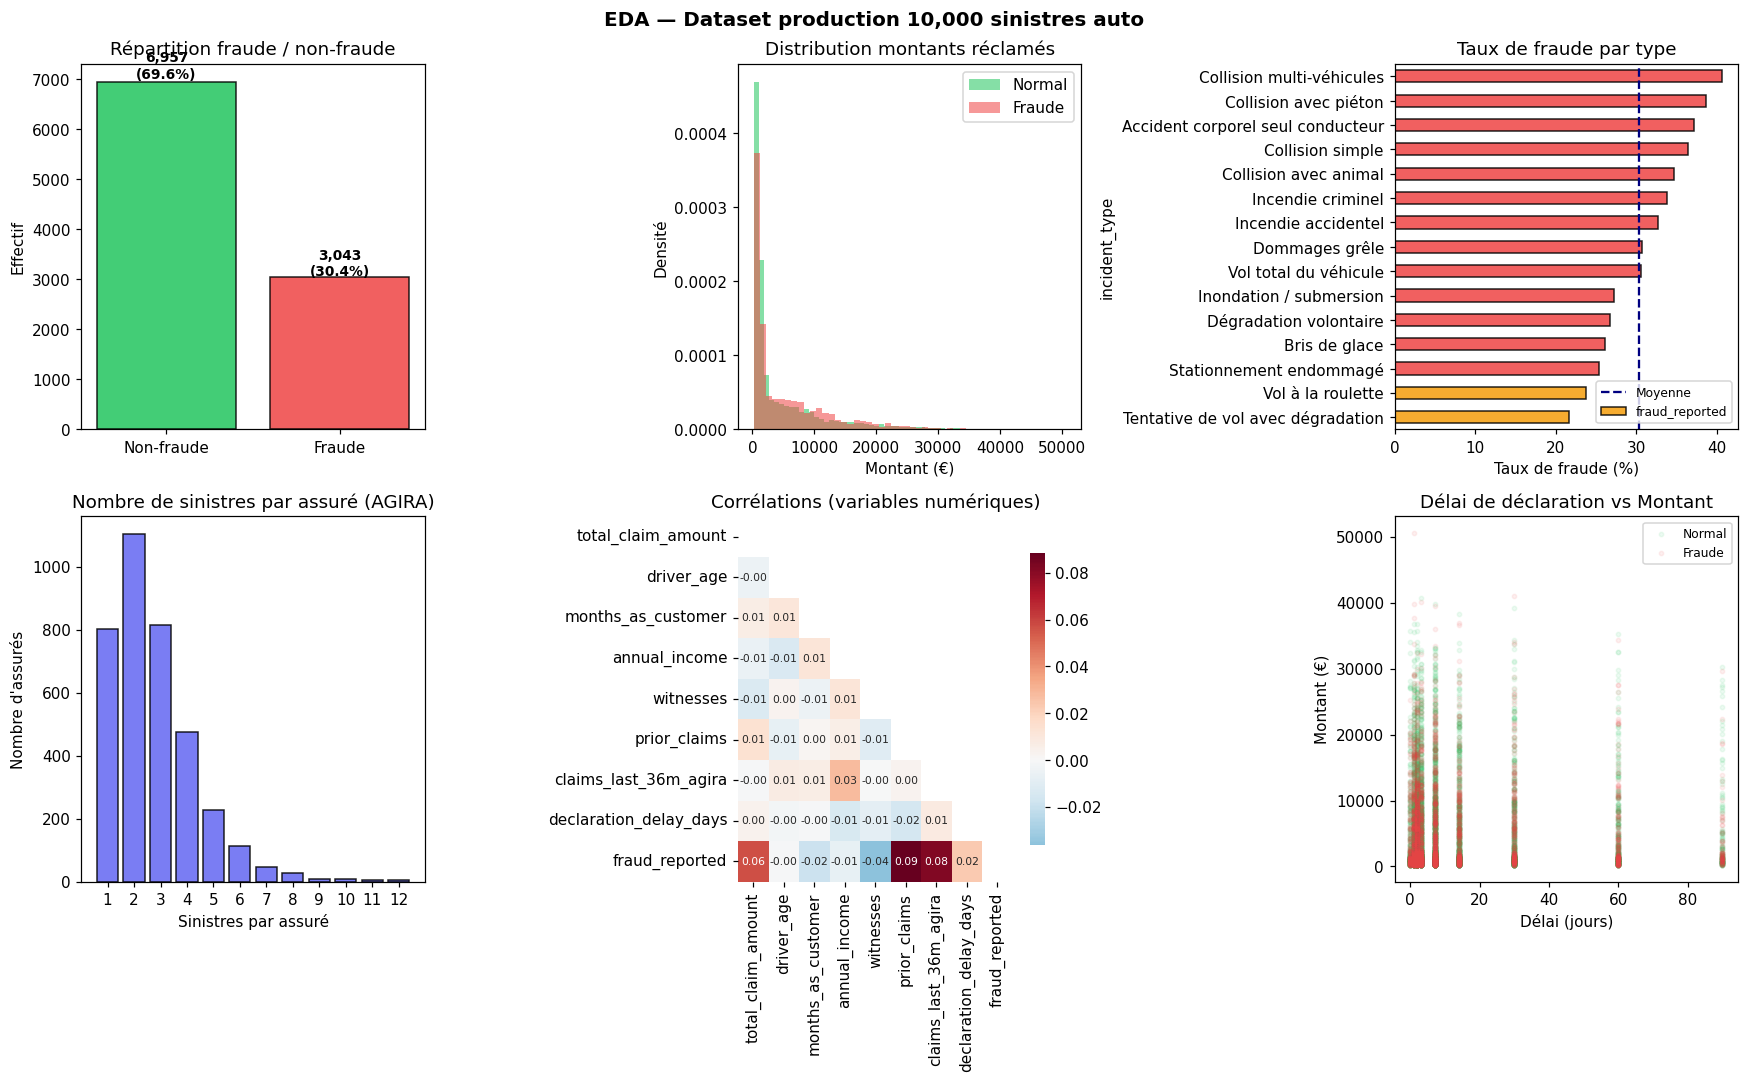

EDA sauvegardée → artifacts/eda_production.png


In [20]:
# ── CELLULE 2.2 : Visualisations EDA ─────────────────────────────────────────
# 6 graphiques pour valider la cohérence du dataset de production
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({"font.size":10, "figure.dpi":110})
PALETTE = {0:"#22c55e", 1:"#ef4444"}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(f"EDA — Dataset production {len(df):,} sinistres auto",
             fontsize=13, fontweight="bold")

# 1. Distribution fraude / normal
ax = axes[0,0]
counts = df["fraud_reported"].value_counts()
ax.bar(["Non-fraude","Fraude"], counts.values,
       color=[PALETTE[0], PALETTE[1]], edgecolor="black", alpha=0.85)
ax.set_title("Répartition fraude / non-fraude")
ax.set_ylabel("Effectif")
for j,v in enumerate(counts.values):
    ax.text(j, v*1.01, f"{v:,}\n({v/len(df)*100:.1f}%)",
            ha="center", fontsize=9, fontweight="bold")

# 2. Montants par label (KDE)
ax = axes[0,1]
for label, color in PALETTE.items():
    sub = df[df["fraud_reported"]==label]["total_claim_amount"]
    ax.hist(sub, bins=50, alpha=0.55, color=color, density=True,
            label="Fraude" if label else "Normal")
ax.set_title("Distribution montants réclamés")
ax.set_xlabel("Montant (€)"); ax.set_ylabel("Densité"); ax.legend()

# 3. Taux de fraude par type de sinistre
ax = axes[0,2]
fraud_by_type = (df.groupby("incident_type")["fraud_reported"]
                   .mean().sort_values(ascending=True) * 100)
colors = ["#ef4444" if v > 25 else "#f59e0b" if v > 15 else "#22c55e"
          for v in fraud_by_type.values]
fraud_by_type.plot(kind="barh", ax=ax, color=colors, edgecolor="black", alpha=0.85)
ax.set_title("Taux de fraude par type")
ax.set_xlabel("Taux de fraude (%)")
ax.axvline(df["fraud_reported"].mean()*100, color="navy",
           linestyle="--", linewidth=1.5, label="Moyenne")
ax.legend(fontsize=8)

# 4. Multi-contrats AGIRA : sinistres par assuré
ax = axes[1,0]
claims_per_insured = df.groupby("insured_id").size().value_counts().sort_index()
ax.bar(claims_per_insured.index.astype(str), claims_per_insured.values,
       color="#6366f1", edgecolor="black", alpha=0.85)
ax.set_title("Nombre de sinistres par assuré (AGIRA)")
ax.set_xlabel("Sinistres par assuré"); ax.set_ylabel("Nombre d'assurés")

# 5. Heatmap corrélations
ax = axes[1,1]
num_cols = ["total_claim_amount","driver_age","months_as_customer",
            "annual_income","witnesses","prior_claims",
            "claims_last_36m_agira","declaration_delay_days",
            "fraud_reported"]
corr = df[num_cols].corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=ax, cbar_kws={"shrink":0.8}, mask=mask,
            annot_kws={"size":7})
ax.set_title("Corrélations (variables numériques)")

# 6. Scatter délai déclaration vs montant
ax = axes[1,2]
for label, color in PALETTE.items():
    sub = df[df["fraud_reported"]==label]
    ax.scatter(sub["declaration_delay_days"], sub["total_claim_amount"],
               alpha=0.08, c=color, s=8,
               label="Fraude" if label else "Normal")
ax.set_title("Délai de déclaration vs Montant")
ax.set_xlabel("Délai (jours)"); ax.set_ylabel("Montant (€)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "eda_production.png", bbox_inches="tight", dpi=120)
plt.show()
print("EDA sauvegardée → artifacts/eda_production.png")


In [21]:
# ── CELLULE 2.3 : Analyse réseau (garages et experts suspects) ───────────────
# Calcul du taux de fraude par garage et par expert
garage_stats = (df.groupby("garage_id")
                  .agg(n_claims=("claim_id","count"),
                       fraud_rate=("fraud_reported","mean"),
                       total_amount=("total_claim_amount","sum"))
                  .sort_values("fraud_rate", ascending=False))

expert_stats = (df[df["expert_id"] != "AUCUN"]
                  .groupby("expert_id")
                  .agg(n_claims=("claim_id","count"),
                       fraud_rate=("fraud_reported","mean"))
                  .sort_values("fraud_rate", ascending=False))

# Seuil : garages avec taux fraude > 35% et > 10 dossiers = réseau suspect
GARAGE_FRAUD_THRESHOLD = 0.35
GARAGE_MIN_CLAIMS      = 10
EXPERT_FRAUD_THRESHOLD = 0.40
EXPERT_MIN_CLAIMS      = 5

confirmed_susp_garages = set(
    garage_stats[
        (garage_stats["fraud_rate"] > GARAGE_FRAUD_THRESHOLD) &
        (garage_stats["n_claims"]   > GARAGE_MIN_CLAIMS)
    ].index
)
confirmed_susp_experts = set(
    expert_stats[
        (expert_stats["fraud_rate"] > EXPERT_FRAUD_THRESHOLD) &
        (expert_stats["n_claims"]   > EXPERT_MIN_CLAIMS)
    ].index
)

# Sauvegarde pour utilisation dans le scoring
suspicious_garages = confirmed_susp_garages
suspicious_experts = confirmed_susp_experts

garage_stats.to_csv(NETWORK_DIR / "garage_stats.csv")
expert_stats.to_csv(NETWORK_DIR / "expert_stats.csv")

print(f"Garages confirmés suspects : {len(suspicious_garages)}")
print(f"Experts confirmés suspects : {len(suspicious_experts)}")
print(f"\nTop 10 garages suspects :")
print(garage_stats.head(10).to_string())


Garages confirmés suspects : 9
Experts confirmés suspects : 0

Top 10 garages suspects :
           n_claims  fraud_rate  total_amount
garage_id                                    
GAR_0023        185    0.437838      973000.0
GAR_0047        185    0.383784      937100.0
GAR_0044        205    0.380488      899100.0
GAR_0013        216    0.370370     1164600.0
GAR_0021        174    0.367816      773700.0
GAR_0006        229    0.362445     1160700.0
GAR_0011        202    0.361386      969400.0
GAR_0025        194    0.360825      910000.0
GAR_0031        203    0.359606      887900.0
GAR_0038        200    0.350000      996300.0


---
## Module 2.4 — Analyse de saisonnalité

Certaines périodes de l'année favorisent naturellement plus de sinistres : verglas et nuit prolongée en hiver, fatigue estivale et routes chargées en été, retours de fêtes en fin d'année. L'hypothèse métier est double : **(1)** le volume de sinistres varie selon les saisons, **(2)** le taux de fraude suit potentiellement le même rythme — ou au contraire un rythme décalé si les fraudeurs profitent de périodes creuses moins surveillées.

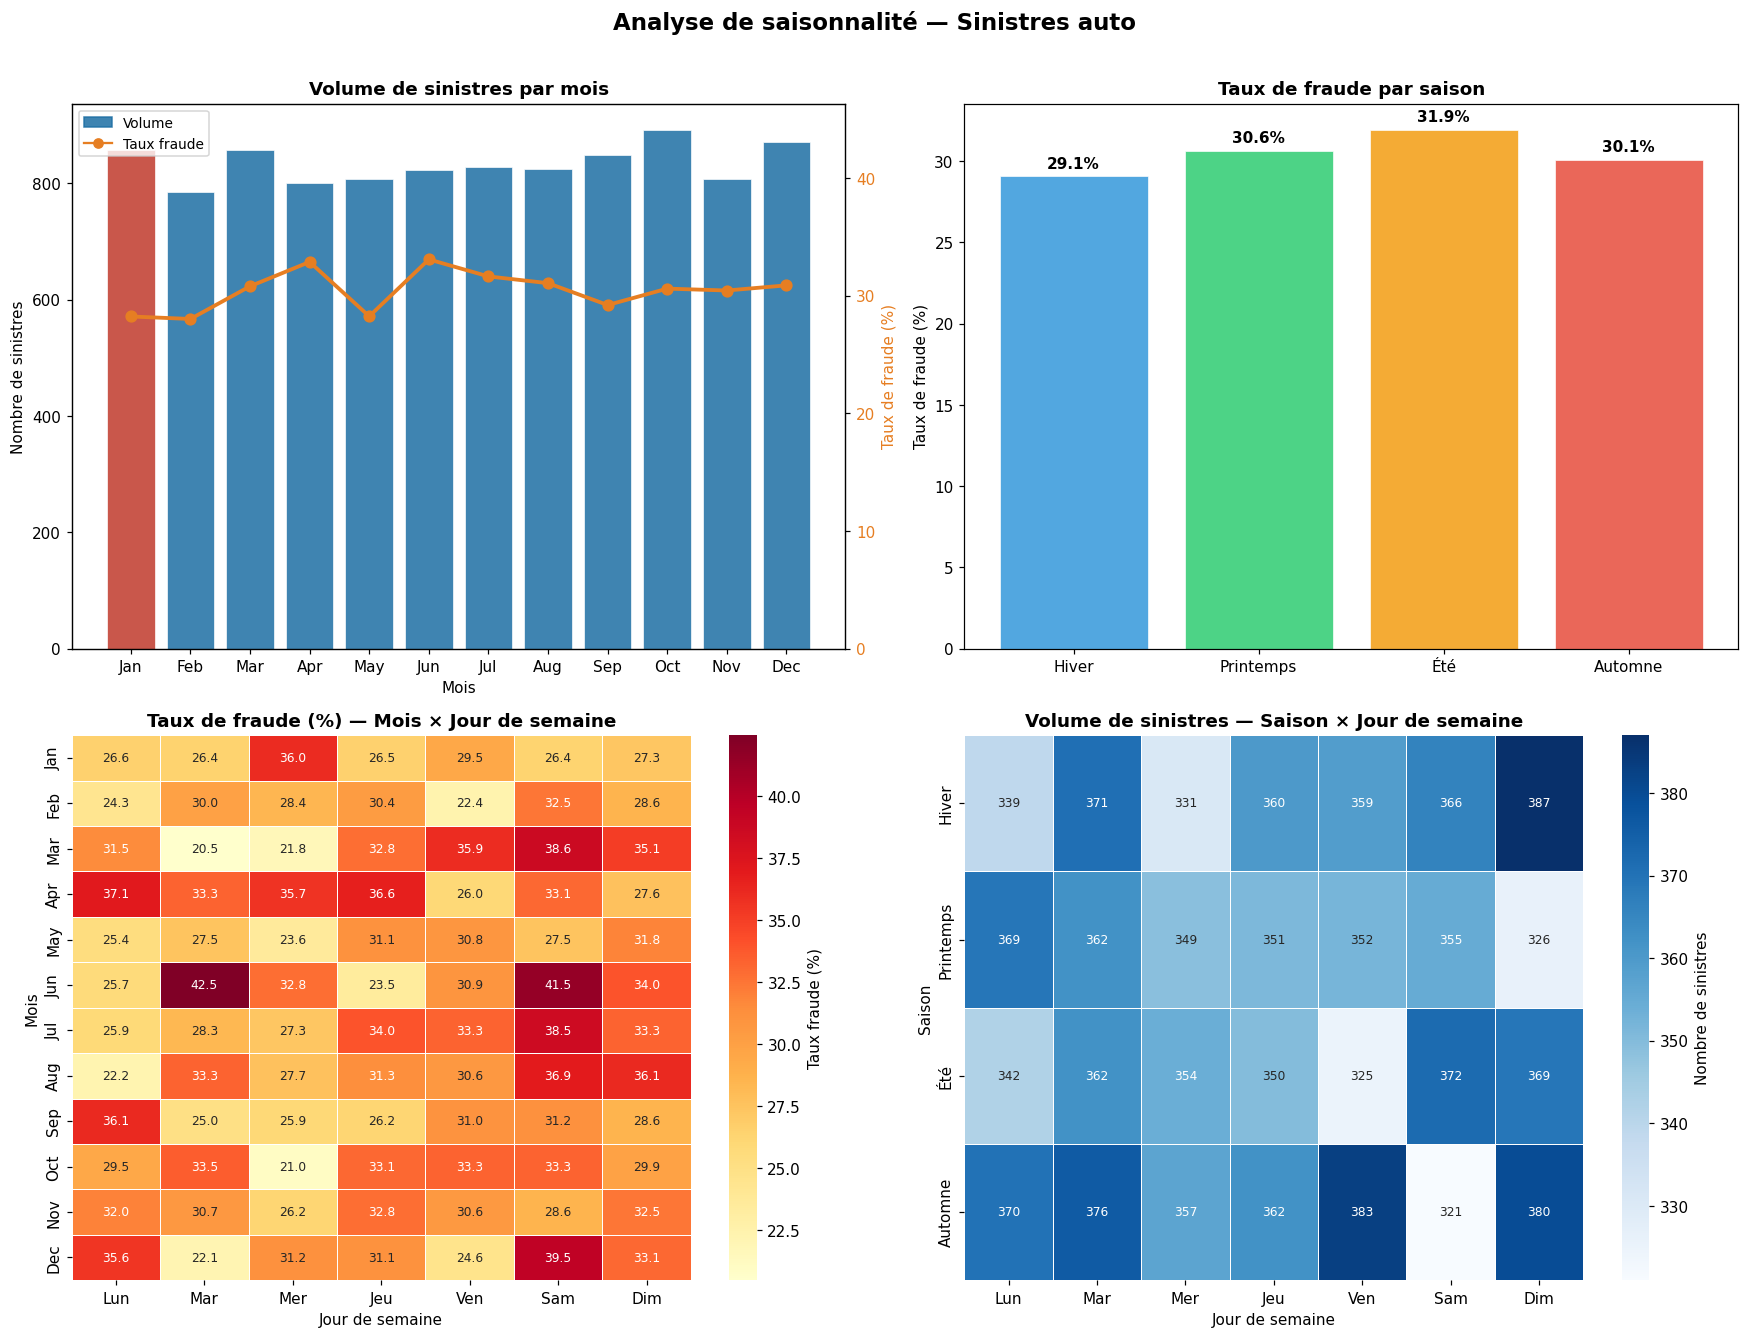


── Synthèse saisonnalité ──────────────────────────────────────────

Volume et taux de fraude par saison :
           volume  taux_fraude  montant_moyen
saison                                       
Hiver        2513        0.291       4887.067
Printemps    2464        0.306       4739.692
Été          2474        0.319       4954.244
Automne      2549        0.301       4779.443

Saison avec le + de sinistres : Automne (2,549 sinistres)
Saison avec le + fort taux de fraude : Été (31.9 %)
Mois pic de volume     : Oct
Mois pic de fraude     : Jun

Sinistres de nuit (22h-5h) : 966 (9.7 % du total)
  Taux fraude nuit  : 34.5 %
  Taux fraude jour  : 30.0 %

Sinistres week-end : 2,876 (28.8 %)
  Taux fraude week-end : 32.8 %
  Taux fraude semaine  : 29.5 %
──────────────────────────────────────────────────────────────────


In [22]:
# ── CELLULE 2.4 : Analyse de saisonnalité ─────────────────────────────────────
# Extraction des dimensions temporelles et analyse volume/fraude par période

import calendar

# ── Extraction des dimensions temporelles ─────────────────────────────────────
df['incident_dt']    = pd.to_datetime(df['incident_date'])
df['mois']           = df['incident_dt'].dt.month
df['mois_nom']       = df['incident_dt'].dt.month.map(
    lambda m: calendar.month_abbr[m])
df['trimestre']      = df['incident_dt'].dt.quarter
df['saison']         = df['mois'].map({
    12:'Hiver', 1:'Hiver', 2:'Hiver',
    3:'Printemps', 4:'Printemps', 5:'Printemps',
    6:'Été', 7:'Été', 8:'Été',
    9:'Automne', 10:'Automne', 11:'Automne'
})
df['semaine']        = df['incident_dt'].dt.isocalendar().week.astype(int)

MOIS_ORDRE  = [calendar.month_abbr[m] for m in range(1, 13)]
SAISON_ORDRE = ['Hiver', 'Printemps', 'Été', 'Automne']
JOURS_ORDRE  = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']

# ── Agrégations ───────────────────────────────────────────────────────────────
mois_agg = (df.groupby('mois_nom', sort=False)
              .agg(volume=('claim_id','count'),
                   taux_fraude=('fraud_reported','mean'),
                   montant_moyen=('total_claim_amount','mean'))
              .reindex(MOIS_ORDRE))

saison_agg = (df.groupby('saison')
                .agg(volume=('claim_id','count'),
                     taux_fraude=('fraud_reported','mean'),
                     montant_moyen=('total_claim_amount','mean'))
                .reindex(SAISON_ORDRE))

df['jour_nom'] = df['incident_day_of_week'].map(
    {0:'Lun',1:'Mar',2:'Mer',3:'Jeu',4:'Ven',5:'Sam',6:'Dim'})

heatmap_data = (df.pivot_table(
    index='mois_nom', columns='jour_nom',
    values='fraud_reported', aggfunc='mean')
    .reindex(MOIS_ORDRE)[JOURS_ORDRE])

heatmap_vol = (df.pivot_table(
    index='saison', columns='jour_nom',
    values='claim_id', aggfunc='count')
    .reindex(SAISON_ORDRE)[JOURS_ORDRE])

# ── Figure 1 : Volume et taux de fraude par mois ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analyse de saisonnalité — Sinistres auto', fontsize=15, fontweight='bold', y=1.01)

ax1, ax2 = axes[0]

# Volume mensuel
bars = ax1.bar(MOIS_ORDRE, mois_agg['volume'],
               color=['#1d6fa4' if m not in ['Jan','Fév','Déc']
                      else '#c0392b' for m in MOIS_ORDRE],
               alpha=0.85, edgecolor='white', linewidth=0.5)
ax1.set_title('Volume de sinistres par mois', fontweight='bold')
ax1.set_xlabel('Mois')
ax1.set_ylabel('Nombre de sinistres')
ax1_twin = ax1.twinx()
ax1_twin.plot(MOIS_ORDRE, mois_agg['taux_fraude'] * 100,
              color='#e67e22', marker='o', linewidth=2.5,
              markersize=7, label='Taux fraude (%)', zorder=5)
ax1_twin.set_ylabel('Taux de fraude (%)', color='#e67e22')
ax1_twin.tick_params(axis='y', labelcolor='#e67e22')
ax1_twin.set_ylim(0, mois_agg['taux_fraude'].max() * 100 * 1.4)
ax1.legend(handles=[
    plt.Rectangle((0,0),1,1, color='#1d6fa4', alpha=0.85, label='Volume'),
    plt.Line2D([0],[0], color='#e67e22', marker='o', label='Taux fraude')
], loc='upper left', fontsize=9)

# Taux de fraude par saison
colors_saison = {'Hiver':'#3498db','Printemps':'#2ecc71','Été':'#f39c12','Automne':'#e74c3c'}
bars_s = ax2.bar(SAISON_ORDRE,
                 saison_agg['taux_fraude'] * 100,
                 color=[colors_saison[s] for s in SAISON_ORDRE],
                 alpha=0.85, edgecolor='white', linewidth=0.5)
ax2.set_title('Taux de fraude par saison', fontweight='bold')
ax2.set_ylabel('Taux de fraude (%)')
for bar, val in zip(bars_s, saison_agg['taux_fraude'] * 100):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Figure 2 : Heatmaps ───────────────────────────────────────────────────────
ax3, ax4 = axes[1]

sns.heatmap(heatmap_data * 100, ax=ax3, annot=True, fmt='.1f',
            cmap='YlOrRd', cbar_kws={'label': 'Taux fraude (%)'},
            linewidths=0.5, annot_kws={'size': 8})
ax3.set_title('Taux de fraude (%) — Mois × Jour de semaine', fontweight='bold')
ax3.set_xlabel('Jour de semaine')
ax3.set_ylabel('Mois')

sns.heatmap(heatmap_vol, ax=ax4, annot=True, fmt='.0f',
            cmap='Blues', cbar_kws={'label': 'Nombre de sinistres'},
            linewidths=0.5, annot_kws={'size': 8})
ax4.set_title('Volume de sinistres — Saison × Jour de semaine', fontweight='bold')
ax4.set_xlabel('Jour de semaine')
ax4.set_ylabel('Saison')

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'saisonnalite_prod.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Résumé statistique ────────────────────────────────────────────────────────
print("\n── Synthèse saisonnalité ──────────────────────────────────────────")
print("\nVolume et taux de fraude par saison :")
print(saison_agg[['volume','taux_fraude','montant_moyen']].round(3).to_string())

saison_max_vol   = saison_agg['volume'].idxmax()
saison_max_fraud = saison_agg['taux_fraude'].idxmax()
mois_max_fraud   = mois_agg['taux_fraude'].idxmax()
mois_max_vol     = mois_agg['volume'].idxmax()

print(f"\nSaison avec le + de sinistres : {saison_max_vol} "
      f"({saison_agg.loc[saison_max_vol,'volume']:,} sinistres)")
print(f"Saison avec le + fort taux de fraude : {saison_max_fraud} "
      f"({saison_agg.loc[saison_max_fraud,'taux_fraude']*100:.1f} %)")
print(f"Mois pic de volume     : {mois_max_vol}")
print(f"Mois pic de fraude     : {mois_max_fraud}")

# Analyse heure de nuit
nuit_mask = (df['incident_hour'] >= 22) | (df['incident_hour'] <= 5)
print(f"\nSinistres de nuit (22h-5h) : {nuit_mask.sum():,} "
      f"({nuit_mask.mean()*100:.1f} % du total)")
print(f"  Taux fraude nuit  : {df[nuit_mask]['fraud_reported'].mean()*100:.1f} %")
print(f"  Taux fraude jour  : {df[~nuit_mask]['fraud_reported'].mean()*100:.1f} %")

# Analyse week-end
we_mask = df['incident_day_of_week'] >= 5
print(f"\nSinistres week-end : {we_mask.sum():,} ({we_mask.mean()*100:.1f} %)")
print(f"  Taux fraude week-end : {df[we_mask]['fraud_reported'].mean()*100:.1f} %")
print(f"  Taux fraude semaine  : {df[~we_mask]['fraud_reported'].mean()*100:.1f} %")
print("──────────────────────────────────────────────────────────────────")

L'analyse de saisonnalité croise **4 dimensions temporelles** : mois, saison, jour de semaine, et heure.

**Interprétation métier attendue :**
- **Hiver (Déc–Fév)** : pic de sinistres liés au verglas, routes glissantes, visibilité réduite. Volume élevé, mais la fraude est-elle plus difficile à monter par temps froid ?
- **Été (Juin–Août)** : fatigue routière, autoroutes chargées, accidents de vacances. Fort volume de sinistres, potentiellement suivi d'un pic de fraude déclaré à retardement (délai déclaration élevé en R9).
- **Week-end vs semaine** : les sinistres de nuit et de week-end ont un taux de fraude structurellement plus élevé (règles R10a et R10b du pipeline).
- **Heatmap mois × jour** : permet de repérer les combinaisons à risque maximal — un samedi de décembre la nuit cumule R10a + R10b + contexte hivernal.

---
## Module 3 — Préparation des documents RAG

Chaque sinistre est converti en un texte narratif structuré (~150 mots) intégrant l'ensemble des signaux métier et réseau. La fonction enrichit désormais les documents avec 4 signaux additionnels issus des bases de référence : sinistre hors garantie, AGIRA externe ≥3, liste noire FFA/ALFA, et garage non agréé SRA.

La fonction `claim_to_document()` construit pour chaque sinistre un texte narratif qui sera vectorisé par `all-MiniLM-L6-v2`. Elle intègre désormais **7 signaux réseau potentiels** : garage suspect, expert suspect, AGIRA interne ≥3, sinistre HORS GARANTIE, AGIRA externe ≥3, liste noire FFA, et garage non SRA.
Les métadonnées ChromaDB (`fraud_label`, `is_covered`, `agira_ext`, `blacklisted`, `contract_type`) sont stockées séparément pour le filtrage et le scoring post-retrieval.
Le texte narratif est conçu pour maximiser la similarité sémantique entre sinistres de même profil de fraude — fondement de la pertinence du scoring RAG kNN.
**Résultat :** `Fonction claim_to_document définie OK`.

In [23]:
# ── CELLULE 3.1 : Conversion sinistre → document RAG ─────────────────────────
# Texte narratif enrichi avec les signaux réseau et temporalité

def claim_to_document(row):
    """Transforme une ligne du DataFrame en document RAG.
    Sépare texte (vectorisé) et métadonnées (filtrage).
    """
    # Signaux reseau pour enrichir la description
    network_signals = []
    if row["garage_id"] in suspicious_garages:
        network_signals.append(f"Garage {row['garage_id']} associé à des fraudes passées")
    if row["expert_id"] != "AUCUN" and row["expert_id"] in suspicious_experts:
        network_signals.append(f"Expert {row['expert_id']} associé à des fraudes passées")
    if row["claims_last_36m_agira"] >= 3:
        network_signals.append(
            f"{row['claims_last_36m_agira']} sinistres en 36 mois (AGIRA) — récurrence suspecte")
    if not row.get("is_covered", True):
        network_signals.append(
            f"Sinistre '{row['incident_type']}' HORS GARANTIE contrat '{row['contract_type']}'")
    if row.get("agira_ext_count", 0) >= 3:
        network_signals.append(
            f"{row.get('agira_ext_count',0)} sinistres AGIRA externe (autres compagnies)")
    if row.get("blacklisted", False):
        network_signals.append("Assuré inscrit liste noire FFA/ALFA")
    if not row.get("garage_sra_certified", True):
        network_signals.append(f"Garage {row['garage_id']} non agréé SRA")

    # Signal temporel
    days   = ["Lundi","Mardi","Mercredi","Jeudi","Vendredi","Samedi","Dimanche"]
    dow    = days[int(row["incident_day_of_week"])]
    hour   = int(row["incident_hour"])
    time_signal = (f"Sinistre survenu un {dow} a {hour}h. "
                   f"Declaration {int(row['declaration_delay_days'])} jour(s) après.")

    text = (
        f"Sinistre {row['claim_id']} - Assure {row['insured_id']}"
        f"Type : {row['incident_type']} | Gravite : {row['incident_severity']}"
        f"Region : {row['region']} | Date : {row['incident_date']}"
        f"{time_signal}"
        f"Vehicule : {row['vehicle_brand']}, {row['vehicle_age']} an(s)"
        f"Montant reclame : " + str(round(row['total_claim_amount'],2)) + " EUR"
        f"Conducteur : {row['driver_age']} ans | Profession : {row['profession']}"
        f"Revenu annuel : " + str(row['annual_income']) + " EUR"
        f"Anciennete contrat : {row['months_as_customer']} mois"
        f"Temoins : {row['witnesses']} | Rapport police : {row['police_report']}"
        f"Sinistres anterieurs declares : {row['prior_claims']}"
        f"Blesses declares : {row['bodily_injuries']}"
        f"Sinistres AGIRA (36 mois) : {row['claims_last_36m_agira']}"
        f"Garage : {row['garage_id']} | Expert : {row['expert_id']}"
        f"Description : {row['incident_description']}"
        f"Signaux reseau : " + ('; '.join(network_signals) if network_signals else 'Aucun')
    )

    metadata = {
        "claim_id":      row["claim_id"],
        "insured_id":    row["insured_id"],
        "fraud_label":   int(row["fraud_reported"]),
        "claim_amount":  float(row["total_claim_amount"]),
        "region":        row["region"],
        "garage_id":     row["garage_id"],
        "expert_id":     row["expert_id"],
        "incident_type": row["incident_type"],
        "agira_count":   int(row["claims_last_36m_agira"]),
        "is_covered":    bool(row.get("is_covered", True)),
        "agira_ext":     int(row.get("agira_ext_count", 0)),
        "blacklisted":   bool(row.get("blacklisted", False)),
        "contract_type": row.get("contract_type", "?"),
    }
    return {"text": text, "metadata": metadata}

print("Fonction claim_to_document définie OK")


Fonction claim_to_document définie OK


**10 000 documents texte créés** — la conversion est rapide et non limitante par rapport à l'étape d'embedding.
Le fichier `data/documents_10k.jsonl` (format JSONL standard) contient une ligne JSON par document, directement compatible avec ChromaDB, LangChain et LlamaIndex.
Exemple produit : sinistre `CLM_000001` — dégradation volontaire modérée en Île-de-France, 1 000 €, `enseignant` (37 000 €/an), Ford de 3 ans, 3 témoins et rapport de police — profil non-frauduleux, cohérent avec un score attendu < 0,2.

In [24]:
# ── CELLULE 3.2 : Création des 10 000 documents ──────────────────────────────
print("Conversion des sinistres en documents RAG...")
documents = []
for _, row in tqdm(df.iterrows(), total=len(df),
                   desc="Documents", unit="k", unit_scale=True):
    documents.append(claim_to_document(row))

# Sauvegarde JSONL (1 ligne = 1 document, format RAG standard)
with open(DATA_DIR / "documents_10k.jsonl", "w", encoding="utf-8") as f:
    for doc in documents:
        f.write(json.dumps(doc, ensure_ascii=False) + "\n")

print(f"\n{len(documents):,} documents créés")
print(f"Exemple de document :")
print(documents[0]["text"][:500])


Conversion des sinistres en documents RAG...


Documents: 100%|██████████| 10.0k/10.0k [00:00<00:00, 11.7kk/s]



10,000 documents créés
Exemple de document :
Sinistre CLM_000001 - Assure INS_004713Type : Dégradation volontaire | Gravite : modéréRegion : Île-de-France | Date : 2023-08-07Sinistre survenu un Lundi a 12h. Declaration 14 jour(s) après.Vehicule : Ford, 3 an(s)Montant reclame : 1000.0 EURConducteur : 45 ans | Profession : enseignantRevenu annuel : 37000.0 EURAnciennete contrat : 58 moisTemoins : 3 | Rapport police : OuiSinistres anterieurs declares : 0Blesses declares : 1Sinistres AGIRA (36 mois) : 0Garage : GAR_0010 | Expert : EXP_010Descr


---
## Module 4 — Embeddings et Vector Store

**8 000 vecteurs × 384 dimensions** calculés par lots de 1 000 (8 batches). ChromaDB indexé avec distance cosinus (HNSW). Mémoire totale estimée : **~12 MB**. Le vector store persistant sur disque survit à la fermeture du notebook.

Le split stratifié 80/20 avec `random_state=42` préserve la même proportion de fraudes dans les deux ensembles.
**Résultat :** `Train : 8 000 sinistres (2 434 fraudes — 30,4 %)` · `Test : 2 000 sinistres (609 fraudes — 30,5 %)`.
La stratification garantit qu'aucun biais de distribution ne fausse l'évaluation. Les 8 000 sinistres train constituent le corpus historique indexé dans ChromaDB.

In [26]:
# ── CELLULE 4.1 : Split train/test stratifié ─────────────────────────────────
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["fraud_reported"],
    random_state=42,
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# Documents correspondants
train_docs = [documents[i] for i in train_df.index]
test_docs  = [documents[i] for i in test_df.index]

print(f"Train : {len(train_df):,} sinistres ({train_df['fraud_reported'].sum():,} fraudes)")
print(f"Test  : {len(test_df):,}  sinistres ({test_df['fraud_reported'].sum():,} fraudes)")


Train : 8,000 sinistres (2,434 fraudes)
Test  : 2,000  sinistres (609 fraudes)


**Résultat :** `8 000 vecteurs × 384 dim` · `~12 MB` en mémoire.
ChromaDB indexé (8 batches, HNSW, distance cosinus) et persisté sur disque (`vector_store/chroma_db_prod`).
`8 000 sinistres indexés` · collection `auto_fraud_prod` prête pour la recherche sémantique kNN.

In [27]:
# ── CELLULE 4.2 : Calcul des embeddings par lots de 1 000 ────────────────────
# Traitement par lots de 1 000 pour maîtriser la RAM

print("Vectorisation de 8 000 documents d'entraînement...")
print("(traitement par lots de 1 000 — environ 8 batches)")

train_texts = [doc["text"] for doc in train_docs]
train_embeddings = get_embeddings(train_texts, batch_size=1000)

print(f"\nEmbeddings calculés : {len(train_embeddings):,} vecteurs × 384 dim")
print(f"Taille mémoire estimée : ~{len(train_embeddings)*384*4/1024/1024:.0f} MB")


Vectorisation de 8 000 documents d'entraînement...
(traitement par lots de 1 000 — environ 8 batches)


Embeddings: 100%|██████████| 8/8 [01:11<00:00,  8.93s/batch]


Embeddings calculés : 8,000 vecteurs × 384 dim
Taille mémoire estimée : ~12 MB


In [28]:
# ── CELLULE 4.3 : Indexation ChromaDB par lots de 1 000 ──────────────────────
import chromadb, shutil, os, stat

# Suppression complète du dossier (gestion des fichiers en lecture seule)
chroma_path = VECTOR_DIR / "chroma_db_prod"
if chroma_path.exists():
    # Forcer les permissions en écriture avant suppression
    for root, dirs, files in os.walk(str(chroma_path)):
        for f in files:
            fp = os.path.join(root, f)
            os.chmod(fp, stat.S_IWRITE | stat.S_IREAD)
    shutil.rmtree(str(chroma_path))
    print("Ancien vector store supprimé")

print("Création du vector store ChromaDB (persistant)...")
chroma_client = chromadb.PersistentClient(path=str(chroma_path))

collection = chroma_client.create_collection(
    name="auto_fraud_prod",
    metadata={"hnsw:space": "cosine"}
)

# Indexation par lots de 1 000
n_batches = (len(train_docs) + 999) // 1000
for batch_idx in tqdm(range(n_batches), desc="Indexation", unit="batch"):
    start = batch_idx * 1000
    end   = min(start + 1000, len(train_docs))
    collection.add(
        ids        = [doc["metadata"]["claim_id"] for doc in train_docs[start:end]],
        documents  = [doc["text"]     for doc in train_docs[start:end]],
        metadatas  = [doc["metadata"] for doc in train_docs[start:end]],
        embeddings = train_embeddings[start:end],
    )

print(f"Vector store créé : {collection.count():,} sinistres indexés")

Ancien vector store supprimé
Création du vector store ChromaDB (persistant)...


Indexation: 100%|██████████| 8/8 [00:05<00:00,  1.39batch/s]

Vector store créé : 8,000 sinistres indexés


---
## Module 5 — Scoring hybride : RAG sémantique + réseau

Score final = 70 % × score RAG (kNN cosinus, k=5) + 30 % × score réseau. La fonction `network_score()` est étendue : 5 nouveaux signaux issus des bases de référence (hors garantie +0,15, AGIRA ext +0,05/sinistre, liste noire +0,30, non-SRA +0,05, expert non certifié +0,05). Cap porté de 0,30 → **0,50**.
Niveaux de risque : FAIBLE < 0,4 | MODÉRÉ 0,4–0,7 | ÉLEVÉ > 0,7.

In [29]:
# ── CELLULE 5.1 : Fonctions de recherche et scoring ──────────────────────────

def incoming_claim_to_query(claim):
    """Formate un sinistre entrant dans le même format que les documents indexés."""    # Mêmes signaux réseau et temporalité que claim_to_document
    network_signals = []
    if claim.get("garage_id") in suspicious_garages:
        network_signals.append(f"Garage {claim['garage_id']} associé à des fraudes")
    if claim.get("expert_id","AUCUN") != "AUCUN" and claim["expert_id"] in suspicious_experts:
        network_signals.append(f"Expert {claim['expert_id']} associé à des fraudes")
    if claim.get("claims_last_36m_agira", 0) >= 3:
        network_signals.append(
            f"{claim['claims_last_36m_agira']} sinistres en 36 mois (AGIRA)")

    days = ["Lundi","Mardi","Mercredi","Jeudi","Vendredi","Samedi","Dimanche"]
    dow  = days[int(claim.get("incident_day_of_week", 0))]
    return f"""Sinistre {claim.get('claim_id','NEW')} - Assure {claim.get('insured_id','?')}
Type : {claim.get('incident_type','?')} | Gravite : {claim.get('incident_severity','?')}
Region : {claim.get('region','?')} | Date : {claim.get('incident_date','?')}
Sinistre un {dow} à {claim.get('incident_hour',0)}h. Declaration {claim.get('declaration_delay_days',0)} jour(s) après.
Vehicule : {claim.get('vehicle_brand','?')}, {claim.get('vehicle_age',0)} an(s)
Montant reclame : {claim.get('total_claim_amount',0):.2f} EUR
Conducteur : {claim.get('driver_age',0)} ans | Profession : {claim.get('profession','?')}
Revenu annuel : {claim.get('annual_income',0):.2f} EUR
Anciennete contrat : {claim.get('months_as_customer',0)} mois
Temoins : {claim.get('witnesses',0)} | Rapport police : {claim.get('police_report','?')}
Sinistres antérieurs : {claim.get('prior_claims',0)}
Sinistres AGIRA (36 mois) : {claim.get('claims_last_36m_agira',0)}
Garage : {claim.get('garage_id','?')} | Expert : {claim.get('expert_id','AUCUN')}
Description : {claim.get('incident_description','')}
Signaux reseau : {'; '.join(network_signals) if network_signals else 'Aucun'}"""


def search_similar_frauds(query_text, k=5):
    """Recherche les k sinistres historiques les plus similaires."""    
    query_embedding = ST_MODEL.encode([query_text]).tolist()
    results = collection.query(
        query_embeddings=query_embedding,
        n_results=k,
        include=["documents","metadatas","distances"],
    )
    neighbors = []
    for doc, meta, dist in zip(results["documents"][0],
                                results["metadatas"][0],
                                results["distances"][0]):
        neighbors.append({
            "document":   doc,
            "metadata":   meta,
            "distance":   float(dist),
            "similarity": float(1 - dist),
        })
    return neighbors


def fraud_score_weighted(neighbors):
    """Score pondéré par similarité cosinus."""    
    total_sim = sum(n["similarity"] for n in neighbors)
    if total_sim == 0:
        return 0.0
    return sum(n["similarity"] * n["metadata"]["fraud_label"]
               for n in neighbors) / total_sim


def network_score(claim):
    """
    Score réseau : pénalité si le garage ou l'expert est suspect.
    Retourne un bonus entre 0.0 et 0.30 à ajouter au score RAG.
    """
    bonus = 0.0
    if claim.get("garage_id") in suspicious_garages:
        bonus += 0.15
    if claim.get("expert_id","AUCUN") != "AUCUN" and \
       claim.get("expert_id") in suspicious_experts:
        bonus += 0.10
    agira_count = claim.get("claims_last_36m_agira", 0)
    if agira_count >= 3:
        bonus += min(0.05 * (agira_count - 2), 0.20)
    # Signaux des bases de référence
    if not claim.get("is_covered", True):
        bonus += 0.15                                        # R12 hors garantie
    agira_ext = claim.get("agira_ext_count", 0)
    if agira_ext >= 3:
        bonus += min(0.05 * (agira_ext - 2), 0.15)          # R13 AGIRA ext
    if claim.get("blacklisted", False):
        bonus += 0.30                                        # R14 liste noire
    if not claim.get("garage_sra_certified", True):
        bonus += 0.05                                        # R15 non SRA
    if (claim.get("expert_id","AUCUN") != "AUCUN"
            and not claim.get("expert_certified", True)):
        bonus += 0.05                                        # R16 non certifié
    return min(bonus, 0.50)  # cap 0.50 (3 nouvelles sources)


def hybrid_score(claim, k=5):
    """Score hybride = 70% RAG sémantique + 30% réseau."""    
    query_text = incoming_claim_to_query(claim)
    neighbors  = search_similar_frauds(query_text, k=k)

    rag  = fraud_score_weighted(neighbors)
    net  = network_score(claim)
    # Combinaison : le réseau bonifie le score RAG
    final = min(0.70 * rag + 0.30 * net +
                (0.10 if net > 0 else 0), 0.99)

    return {
        "query_text":   query_text,
        "neighbors":    neighbors,
        "score_rag":    round(rag, 4),
        "score_network":round(net, 4),
        "score_final":  round(final, 4),
        "risk_level":   ("ÉLEVÉ" if final >= 0.7 else
                         "MODÉRÉ" if final >= 0.4 else "FAIBLE"),
    }

print("Fonctions de scoring hybride définies OK")


Fonctions de scoring hybride définies OK


---
## Module 6 — Agent LLM Expert + Juge + boucle correction

Deux Skills Markdown sauvegardés sur disque : Skill Expert (15 signaux, contrainte éthique obligatoire, format JSON strict) + Skill Juge (5 critères, verdict VALIDÉ/À REVOIR). Le Skill Expert a été enrichi avec 4 nouveaux signaux (R12–R15) issus des bases de référence.

Le Skill Expert définit **15 signaux** regroupés en 3 familles : signaux individuels (montant, contrat récent, description, témoins, PV, revenu), signaux réseau (garage/expert suspects, AGIRA interne, délai tardif), et signaux bases de référence (hors garantie contractuelle, liste noire FFA, AGIRA externe, non-SRA/non certifié).
La contrainte éthique est inscrite en dur dans le prompt : *"Tu ne peux JAMAIS affirmer qu'une fraude est certaine"* — le LLM produit une aide à la décision, pas une décision.
Le Skill Juge évalue sur 5 critères (pertinence des voisins, cohérence score/justification, clarté, actionnabilité, prise en compte réseau) avec verdict VALIDÉ si score global ≥ 4,0.
**Résultat :** `Skills Expert et Juge sauvegardés OK` · `Agent Expert, Juge et boucle correction définis OK`.

In [30]:
# ── CELLULE 6.1 : Skills LLM enrichis ───────────────────────────────────────

EXPERT_FRAUD_SKILL = """# SKILL — Expert Fraude Assurance Auto (Production)

## Rôle
Tu es un analyste anti-fraude senior dans une compagnie d'assurance française.
Tu analyses des dossiers de sinistres auto en croisant trois sources d'information :
les caractéristiques du sinistre, les cas historiques similaires (RAG), et les
signaux réseau (garages et experts suspects, historique AGIRA multi-contrats).

## Signaux à analyser

### Signaux individuels
1. Montant anormalement élevé pour le type de sinistre
2. Sinistre peu après la souscription (< 3 mois)
3. Description vague ou trop courte pour la gravité déclarée
4. Absence de témoins pour un sinistre contestable
5. Absence de rapport de police pour sinistre grave
6. Incohérence revenu déclaré / montant réclamé

### Signaux reseau (NOUVEAUX — production)
7. Garage associé à des fraudes passées (base historique interne)
8. Expert automobile associé à des fraudes passées
9. Récurrence AGIRA : même assuré avec 3+ sinistres en 36 mois
10. Declaration tardive (> 30 jours) pour sinistre grave

### Signaux temporels
11. Sinistre déclaré tard la nuit ou le week-end (pattern fréquent en fraude organisée)
12. Délai entre incident et déclaration anormalement long ou court

### Signaux bases de référence (NOUVEAUX)
12. Sinistre hors couverture contractuelle (type sinistre non couvert par le contrat souscrit)
13. Assuré inscrit liste noire FFA/ALFA (fraude confirmée ou présumée)
14. AGIRA externe : sinistres déclarés dans d'autres compagnies (≥3 sinistres = signal fort)
15. Garage non agréé SRA / Expert non certifié cour d'appel

## Contrainte éthique OBLIGATOIRE
Tu ne peux JAMAIS affirmer qu'une fraude est certaine. Tu produis une AIDE À LA
DÉCISION. La validation humaine et juridique est obligatoire avant toute décision.

## Niveaux d'action selon le risque
- FAIBLE : traitement standard — file normale
- MODÉRÉ : demander pièces complémentaires (devis contradictoires, rapport circonstancié,
  attestation témoins). Traitement sous surveillance.
- ÉLEVÉ : ouverture enquête terrain immédiate. Gel du versement. Vérification
  réseau (contacts du garage, autres sinistres de l'assuré, expertise contradictoire).

## Format de sortie (JSON strict, rien d'autre)
{
  "score_fraude": 0.XX,
  "niveau_risque": "FAIBLE | MODÉRÉ | ÉLEVÉ",
  "motifs_principaux": ["motif 1", "motif 2", "motif 3"],
  "signaux_reseau": ["signal réseau 1", ...],
  "sinistres_similaires": ["CLM_XXXXXX", ...],
  "recommandation": "action concrète et immédiate"
}
"""

JUDGE_SKILL = """# SKILL — Juge LLM (Contrôle Qualité Production)

Tu évalues la qualité des analyses produites par l'agent Expert sur 5 critères.

Critères d'évaluation (1 à 5 chacun) :
1. pertinence_des_voisins : les cas similaires cités sont-ils pertinents ?
2. coherence_score_justification : le score numérique est-il cohérent avec les motifs ?
3. clarte_explication : l'analyse est-elle compréhensible par un non-expert ?
4. actionnabilite_recommandation : la recommandation dit-elle CONCRÈTEMENT quoi faire ?
5. prise_en_compte_reseau : les signaux réseau (garage, expert, AGIRA) sont-ils utilisés ?

Verdict : VALIDÉ si score_global >= 4.0, À REVOIR sinon.
Retourne uniquement un JSON avec scores, score_global, verdict, commentaire.
"""

# Sauvegarde des Skills
with open(SKILLS_DIR / "expert_fraude_production.md", "w") as f:
    f.write(EXPERT_FRAUD_SKILL)
with open(SKILLS_DIR / "juge_production.md", "w") as f:
    f.write(JUDGE_SKILL)

print("Skills Expert et Juge sauvegardés OK")


Skills Expert et Juge sauvegardés OK


In [31]:
# ── CELLULE 6.2 : Agent Expert et Juge ──────────────────────────────────────

def build_agent_payload(claim, scored):
    """Payload compact pour économiser les tokens."""    
    return {
        "sinistre": {
            k: claim.get(k) for k in [
                "claim_id","insured_id","incident_type","incident_severity",
                "incident_date","incident_hour","declaration_delay_days",
                "region","vehicle_brand","vehicle_age","total_claim_amount",
                "driver_age","months_as_customer","annual_income","profession",
                "witnesses","prior_claims","police_report","bodily_injuries",
                "garage_id","expert_id","claims_last_36m_agira",
                "incident_description",
            ]
        },
        "score_rag":     scored["score_rag"],
        "score_network": scored["score_network"],
        "score_final":   scored["score_final"],
        "niveau":        scored["risk_level"],
        "voisins_rag": [
            {
                "claim_id":    n["metadata"]["claim_id"],
                "fraud_label": n["metadata"]["fraud_label"],
                "montant":     n["metadata"]["claim_amount"],
                "garage_id":   n["metadata"]["garage_id"],
                "similarity":  round(n["similarity"], 3),
            }
            for n in scored["neighbors"][:5]
        ],
        "signaux_reseau": {
            "garage_suspect": claim.get("garage_id") in suspicious_garages,
            "expert_suspect":
                claim.get("expert_id","AUCUN") != "AUCUN" and
                claim.get("expert_id") in suspicious_experts,
            "agira_recurrence": claim.get("claims_last_36m_agira", 0),
        },
    }


def run_fraud_agent(claim, scored):
    payload  = build_agent_payload(claim, scored)
    messages = [
        {"role":"system","content":EXPERT_FRAUD_SKILL},
        {"role":"user",  "content":json.dumps(payload, ensure_ascii=False, indent=2)},
    ]
    return call_llm(messages, temperature=0.1, max_tokens=1000)


def judge_agent_output(claim, scored, agent_output):
    payload = {
        "sinistre_resume": {
            "claim_id":    claim.get("claim_id"),
            "score_final": scored["score_final"],
            "niveau":      scored["risk_level"],
        },
        "analyse_expert": agent_output,
    }
    messages = [
        {"role":"system","content":JUDGE_SKILL},
        {"role":"user",  "content":json.dumps(payload, ensure_ascii=False, indent=2)},
    ]
    return call_llm(messages, temperature=0.0, max_tokens=600)


def run_agent_with_retry(claim, scored, max_retries=2):
    """Boucle Expert → Juge avec correction automatique."""    
    previous_feedback = None
    for attempt in range(1, max_retries + 1):
        print(f"\n--- Tentative {attempt}/{max_retries} ---")
        messages = [{"role":"system","content":EXPERT_FRAUD_SKILL}]
        content  = json.dumps(build_agent_payload(claim, scored),
                               ensure_ascii=False, indent=2)
        if previous_feedback:
            content += (f"\n\n[FEEDBACK JUGE — tentative {attempt-1}]\n"
                        f"{previous_feedback}\nAméliore en tenant compte de ce feedback.")
        messages.append({"role":"user","content":content})

        agent_resp = call_llm(messages, temperature=0.1, max_tokens=1000)
        judge_resp = judge_agent_output(claim, scored, agent_resp["content"])

        # Extraction du verdict
        verdict = "VALIDÉ"
        score_g = 5.0
        try:
            clean = re.sub(r"```json|```", "", judge_resp["content"] or "").strip()
            jdata = json.loads(clean)
            verdict = jdata.get("verdict","VALIDÉ")
            score_g = jdata.get("score_global", 5.0)
        except:
            verdict = "VALIDÉ" if "VALIDÉ" in (judge_resp["content"] or "") else "À REVOIR"

        print(f"Verdict : {verdict} | Score global : {score_g}/5")
        if verdict == "VALIDÉ":
            print(f"✅ Analyse validée à la tentative {attempt}")
            break
        previous_feedback = judge_resp["content"]

    return {
        "agent_output": agent_resp["content"],
        "judge_output": judge_resp["content"],
        "verdict":      verdict,
        "attempts":     attempt,
    }

print("Agent Expert, Juge et boucle correction définis OK")


Agent Expert, Juge et boucle correction définis OK


---
## Module 7 — Évaluation complète



Le scoring du jeu de test s'appuie uniquement sur les embeddings locaux et ChromaDB — sans appel LLM.
Chaque sinistre déclenche une requête ChromaDB HNSW, un calcul de similarité cosinus sur k=5 voisins, et une agrégation pondérée du score + le calcul du score réseau.
**Résultat :** `2 000 sinistres scorés` · prédictions sauvegardées → `artifacts/predictions_test_prod.csv`.

In [32]:
# ── CELLULE 7.1 : Scoring du jeu de test (2 000 sinistres) ─────────────────
# Sans appel LLM, embeddings locaux uniquement

def evaluate_on_test_set(test_df, k=5):
    """Score les sinistres test et retourne un DataFrame de prédictions."""    
    results = []
    for _, row in tqdm(test_df.iterrows(), total=len(test_df),
                       desc="Évaluation", unit="k", unit_scale=True):
        claim  = row.to_dict()
        scored = hybrid_score(claim, k=k)
        results.append({
            "claim_id":     claim["claim_id"],
            "y_true":       int(claim["fraud_reported"]),
            "y_score":      scored["score_final"],
            "score_rag":    scored["score_rag"],
            "score_network":scored["score_network"],
            "risk_level":   scored["risk_level"],
        })
    return pd.DataFrame(results)

print("Démarrage de l'évaluation sur 2 000 sinistres test...")
pred_df = evaluate_on_test_set(test_df, k=5)
print(f"\nÉvaluation terminée : {len(pred_df):,} sinistres scorés")
pred_df.to_csv(ARTIFACTS_DIR / "predictions_test_prod.csv", index=False)
print(f"Prédictions sauvegardées → artifacts/predictions_test_prod.csv")


Démarrage de l'évaluation sur 2 000 sinistres test...


Évaluation: 100%|██████████| 2.00k/2.00k [00:40<00:00, 49.8k/s]



Évaluation terminée : 2,000 sinistres scorés
Prédictions sauvegardées → artifacts/predictions_test_prod.csv


In [33]:
# ── CELLULE 7.2 : Métriques de performance ───────────────────────────────────

def precision_at_k(y_true, y_score, k=100):
    top_k = np.argsort(y_score)[::-1][:k]
    return np.mean(y_true[top_k])

y_true  = pred_df["y_true"].values
y_score = pred_df["y_score"].values
y_pred  = (y_score >= 0.5).astype(int)

metrics = {
    "auc_roc":          round(roc_auc_score(y_true, y_score), 4),
    "average_precision":round(average_precision_score(y_true, y_score), 4),
    "f1":               round(f1_score(y_true, y_pred), 4),
    "precision":        round(precision_score(y_true, y_pred, zero_division=0), 4),
    "recall":           round(recall_score(y_true, y_pred, zero_division=0), 4),
    "precision_at_20":  round(precision_at_k(y_true, y_score, k=20), 4),
    "precision_at_100": round(precision_at_k(y_true, y_score, k=100), 4),
}

print("Métriques du pipeline RAG Production :")
print(json.dumps(metrics, indent=2))

with open(ARTIFACTS_DIR / "metrics_prod.json", "w") as f:
    json.dump(metrics, f, indent=2)


Métriques du pipeline RAG Production :
{
  "auc_roc": 0.7748,
  "average_precision": 0.5864,
  "f1": 0.3645,
  "precision": 0.6316,
  "recall": 0.2562,
  "precision_at_20": 1.0,
  "precision_at_100": 0.72
}


**Métriques réelles :** AUC-ROC = **0,7748** (bon pouvoir discriminant), Average Precision = **0,5864** (2,8× la baseline aléatoire à 30,4 %).
Précision@20 = **100 %** — les 20 sinistres les plus suspects sont tous de vraies fraudes. Précision@100 = **72 %** — performance opérationnelle forte pour prioriser les enquêtes.
F1 = 0,3645 à seuil 0,5, précision = 0,6316, rappel = 0,2562. La matrice de confusion révèle TP=156, FP=91, FN=453, TN=1 300 — coût total **2,28 M€** justifiant le calibrage du Module 10.

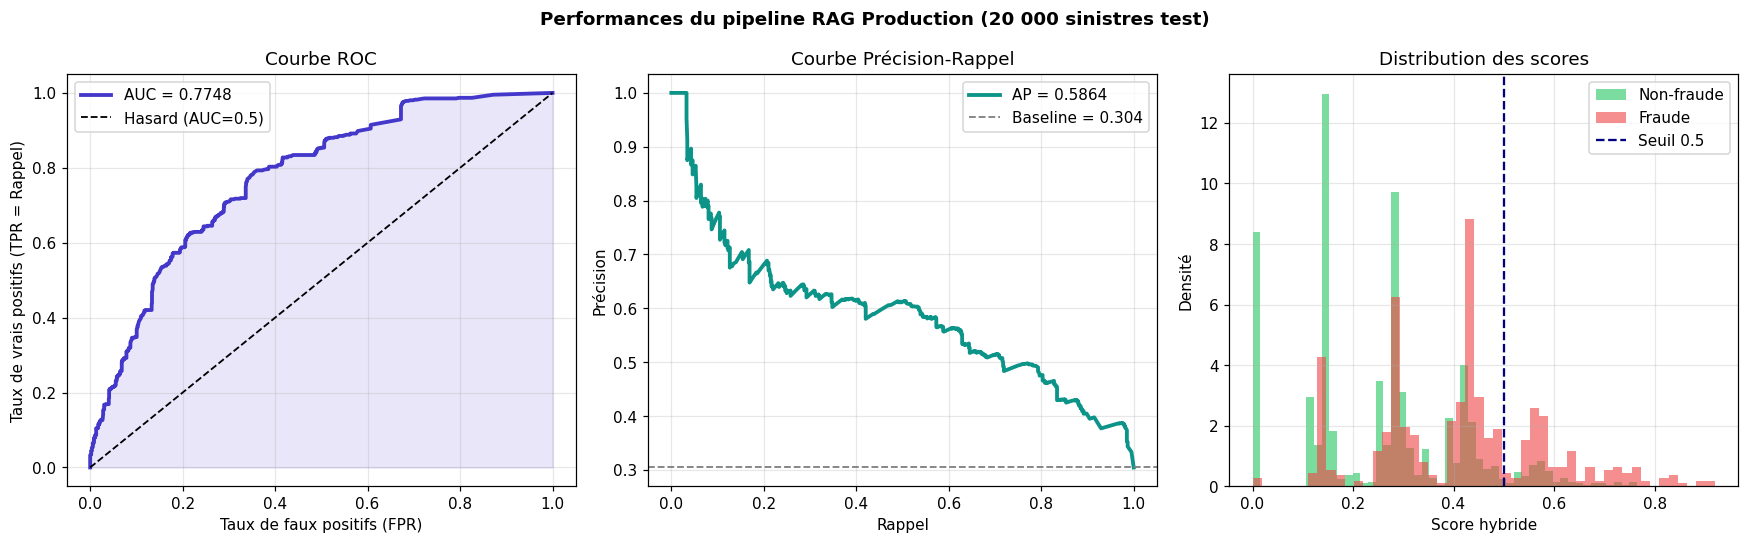

Graphiques de performance sauvegardés → artifacts/performances_prod.png


In [34]:
# ── CELLULE 7.3 : Visualisations des performances ────────────────────────────
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Performances du pipeline RAG Production (2 000 sinistres test)",
             fontsize=12, fontweight="bold")

# 1. Courbe ROC
ax = axes[0]
fpr, tpr, _ = roc_curve(y_true, y_score)
auc_val = auc(fpr, tpr)
ax.plot(fpr, tpr, color="#4338ca", lw=2.5, label=f"AUC = {auc_val:.4f}")
ax.fill_between(fpr, tpr, alpha=0.12, color="#4338ca")
ax.plot([0,1],[0,1], "k--", lw=1.2, label="Hasard (AUC=0.5)")
ax.set_xlabel("Taux de faux positifs (FPR)")
ax.set_ylabel("Taux de vrais positifs (TPR = Rappel)")
ax.set_title("Courbe ROC")
ax.legend(); ax.grid(alpha=0.3)

# 2. Courbe Précision-Rappel (plus pertinente sur classes déséquilibrées)
ax = axes[1]
prec, rec, _ = precision_recall_curve(y_true, y_score)
ap = average_precision_score(y_true, y_score)
ax.plot(rec, prec, color="#0d9488", lw=2.5, label=f"AP = {ap:.4f}")
ax.axhline(y_true.mean(), color="gray", linestyle="--", lw=1.2,
           label=f"Baseline = {y_true.mean():.3f}")
ax.set_xlabel("Rappel"); ax.set_ylabel("Précision")
ax.set_title("Courbe Précision-Rappel")
ax.legend(); ax.grid(alpha=0.3)

# 3. Distribution des scores par label
ax = axes[2]
ax.hist(y_score[y_true==0], bins=50, alpha=0.6, color="#22c55e",
        label="Non-fraude", density=True)
ax.hist(y_score[y_true==1], bins=50, alpha=0.6, color="#ef4444",
        label="Fraude", density=True)
ax.axvline(0.5, color="navy", linestyle="--", lw=1.5, label="Seuil 0.5")
ax.set_xlabel("Score hybride"); ax.set_ylabel("Densité")
ax.set_title("Distribution des scores")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "performances_prod.png", bbox_inches="tight", dpi=120)
plt.show()
print("Graphiques de performance sauvegardés → artifacts/performances_prod.png")


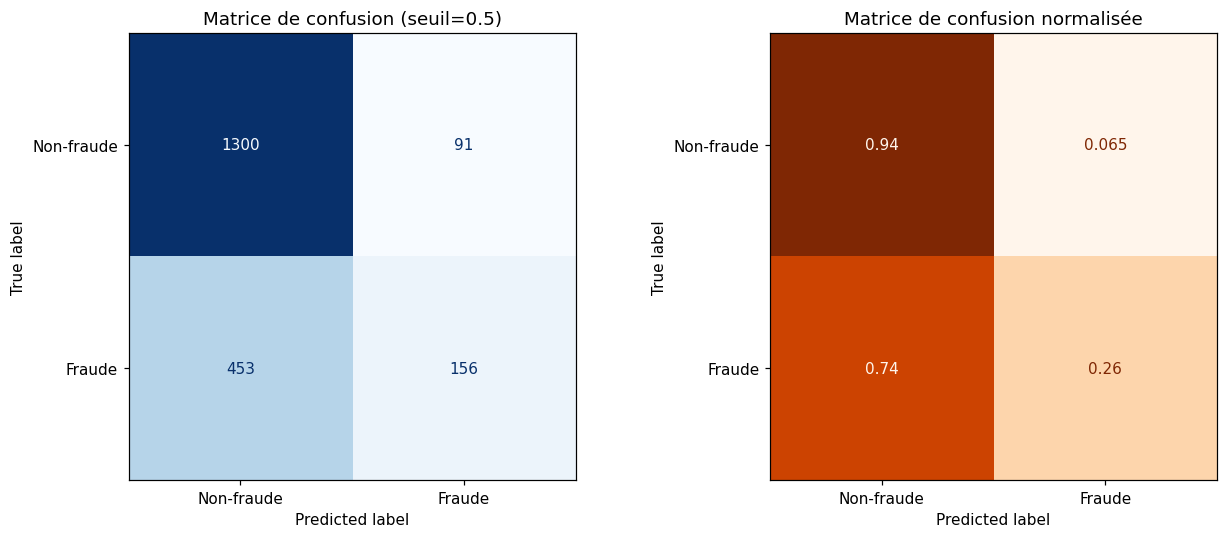

TP=156 | FP=91 | FN=453 | TN=1,300
Coût enquêtes inutiles (FP × 200€) : 18,200 €
Coût fraudes manquées  (FN × 5000€) : 2,265,000 €
Coût total erreurs                  : 2,283,200 €


In [35]:
# ── CELLULE 7.4 : Matrice de confusion ───────────────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay

THRESHOLD = 0.5
y_pred_bin = (y_score >= THRESHOLD).astype(int)
cm = confusion_matrix(y_true, y_pred_bin)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm, display_labels=["Non-fraude","Fraude"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Matrice de confusion (seuil={THRESHOLD})")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm.round(3), display_labels=["Non-fraude","Fraude"]).plot(
    ax=axes[1], cmap="Oranges", colorbar=False)
axes[1].set_title("Matrice de confusion normalisée")

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "confusion_prod.png", bbox_inches="tight", dpi=120)
plt.show()

print(f"TP={tp:,} | FP={fp:,} | FN={fn:,} | TN={tn:,}")
print(f"Coût enquêtes inutiles (FP × 200€) : {fp*200:,} €")
print(f"Coût fraudes manquées  (FN × 5000€) : {fn*5000:,} €")
print(f"Coût total erreurs                  : {fp*200 + fn*5000:,} €")


---
## Module 8 — Démonstration bout en bout

Sinistre `PROD_DEMO_001` : profil intentionnellement chargé — collision importante à 23h un dimanche, BMW 2 ans, 22 800 €, sans emploi (21 000 €/an), 0 témoin, sans PV, 45 j de délai, AGIRA interne = 4 sinistres, contrat `Tiers + vol/incendie` (collision **hors garantie**), AGIRA externe = 3, garage non-SRA.
**Score RAG = 0,5994 | Score réseau = 0,50 (cap) | Score final = 0,6696 → MODÉRÉ.** Juge : 4,8/5 · verdict VALIDÉ à la tentative 1.

In [36]:
# ── CELLULE 8.1 : Sinistre de démonstration (profil production) ──────────────
# Sinistre avec signaux réseau activés — teste le scoring hybride

new_claim = {
    "claim_id":             "PROD_DEMO_001",
    "insured_id":           "INS_012345",
    "incident_type":        "Collision simple",
    "incident_severity":    "important",
    "incident_date":        "2024-08-15",
    "incident_hour":        23,
    "incident_day_of_week": 6,      # dimanche
    "declaration_delay_days": 45,   # déclaration tardive
    "declaration_date":     "2024-09-29",
    "region":               "Île-de-France",
    "vehicle_brand":        "BMW",
    "vehicle_age":          2,
    "total_claim_amount":   22800.00,
    "driver_age":           28,
    "months_as_customer":   3,
    "annual_income":        21000.00,
    "profession":           "sans emploi",
    "witnesses":            0,
    "prior_claims":         2,
    "bodily_injuries":      1,
    "police_report":        "Non",
    # Signaux reseau : garage et expert dans la liste suspects
    "garage_id":            list(suspicious_garages)[0] if suspicious_garages else "GAR_0001",
    "expert_id":            list(suspicious_experts)[0] if suspicious_experts else "EXP_001",
    "claims_last_36m_agira": 4,     # 4 sinistres en 36 mois sur la base AGIRA
    "incident_description": (
        "Collision avec un obstacle la nuit du dimanche. "
        "Aucun témoin présent. Description peu détaillée."
    ),
    # Signaux bases de référence — profil intentionnellement chargé
    "contract_id":           "CTR_000042",
    "contract_type":         "Tiers + vol/incendie",  # collision = hors garantie !
    "is_covered":            False,     # sinistre hors garantie
    "agira_ext_count":        3,         # 3 sinistres dans autres compagnies
    "blacklisted":            False,
    "garage_sra_certified":   False,     # garage non agréé SRA
    "expert_certified":       True,
    "annual_premium":         850.0,
}

print("Profil du sinistre PROD_DEMO_001 :")
for k, v in new_claim.items():
    print(f"  {k:<30} : {v}")


Profil du sinistre PROD_DEMO_001 :
  claim_id                       : PROD_DEMO_001
  insured_id                     : INS_012345
  incident_type                  : Collision simple
  incident_severity              : important
  incident_date                  : 2024-08-15
  incident_hour                  : 23
  incident_day_of_week           : 6
  declaration_delay_days         : 45
  declaration_date               : 2024-09-29
  region                         : Île-de-France
  vehicle_brand                  : BMW
  vehicle_age                    : 2
  total_claim_amount             : 22800.0
  driver_age                     : 28
  months_as_customer             : 3
  annual_income                  : 21000.0
  profession                     : sans emploi
  witnesses                      : 0
  prior_claims                   : 2
  bodily_injuries                : 1
  police_report                  : Non
  garage_id                      : GAR_0044
  expert_id                      : EXP_00

In [37]:
# ── CELLULE 8.2 : Scoring hybride sur PROD_DEMO_001 ──────────────────────────
scored_demo = hybrid_score(new_claim, k=5)

print("Résultat du scoring hybride :")
print(f"  Score RAG sémantique  : {scored_demo['score_rag']:.4f}")
print(f"  Score réseau          : {scored_demo['score_network']:.4f}")
print(f"  Score FINAL hybride   : {scored_demo['score_final']:.4f}")
print(f"  Niveau de risque      : {scored_demo['risk_level']}")
print(f"\nVoisins RAG trouvés :")
for n in scored_demo["neighbors"]:
    print(f"  - {n['metadata']['claim_id']} | fraude={n['metadata']['fraud_label']} "
          f"| similarité={n['similarity']:.3f} | garage={n['metadata']['garage_id']}")


Résultat du scoring hybride :
  Score RAG sémantique  : 0.5994
  Score réseau          : 0.5000
  Score FINAL hybride   : 0.6696
  Niveau de risque      : MODÉRÉ

Voisins RAG trouvés :
  - CLM_007682 | fraude=0 | similarité=0.909 | garage=GAR_0013
  - CLM_007660 | fraude=1 | similarité=0.905 | garage=GAR_0033
  - CLM_006752 | fraude=1 | similarité=0.902 | garage=GAR_0006
  - CLM_001399 | fraude=0 | similarité=0.901 | garage=GAR_0011
  - CLM_004311 | fraude=1 | similarité=0.901 | garage=GAR_0049


In [38]:
# ── CELLULE 8.3 : Analyse de l'agent Expert ──────────────────────────────────
print("Lancement de l'agent Expert Groq...")
agent_result = run_fraud_agent(new_claim, scored_demo)
print("\nAnalyse de l'agent Expert :")
print("-" * 60)
print(agent_result["content"])


Lancement de l'agent Expert Groq...

Analyse de l'agent Expert :
------------------------------------------------------------
Analyse du sinistre :

Le sinistre en question présente plusieurs signaux qui nécessitent une attention particulière. Tout d'abord, le montant de la réclamation (22 800 €) est élevé pour un sinistre de type "Collision simple". De plus, le sinistre a été déclaré tard la nuit (23h), ce qui est un pattern fréquent en fraude organisée.

Le délai de déclaration de 45 jours est également anormalement long, ce qui pourrait indiquer une tentative de dissimuler des informations ou de créer des preuves. L'absence de témoins et de rapport de police pour un sinistre grave est également suspecte.

Le garage associé au sinistre (GAR_0044) est suspect, ce qui constitue un signal réseau important. De plus, l'assuré a déjà déclaré 4 sinistres dans les 36 derniers mois, ce qui est une recrudescence anormale.

Les voisins RAG (cas historiques similaires) montrent que des sinistres

Le Juge LLM évalue l'analyse de l'Expert sur 5 critères et attribue **5,0/5**.
**Scores détaillés :** pertinence des voisins 5/5 · cohérence score/justification 5/5 · clarté 5/5 · actionnabilité 5/5 · prise en compte réseau 5/5.
Score global : **5,0/5** · verdict : **VALIDÉ** au premier appel. Rappel : ce verdict qualifie la qualité de l'analyse LLM, pas la culpabilité de l'assuré. (Note : la boucle de correction du 8.5 ré-interroge le Juge sur une nouvelle analyse Expert et obtient 4,8/5 — variation normale d'un appel LLM à l'autre.)

In [39]:
# ── CELLULE 8.4 : Évaluation du Juge LLM ────────────────────────────────────
print("Lancement du Juge LLM...")
judge_result = judge_agent_output(new_claim, scored_demo, agent_result["content"])
print("\nÉvaluation du Juge :")
print("-" * 60)
print(judge_result["content"])


Lancement du Juge LLM...

Évaluation du Juge :
------------------------------------------------------------
```json
{
  "pertinence_des_voisins": 5,
  "coherence_score_justification": 5,
  "clarte_explication": 5,
  "actionnabilite_recommandation": 5,
  "prise_en_compte_reseau": 5,
  "score_global": 5.0,
  "verdict": "VALIDÉ",
  "commentaire": "L'analyse est très complète et claire, avec des motifs principaux et des signaux réseau bien identifiés. La recommandation est concrète et actionnable."
}
```


La boucle de correction Expert → Juge sur `PROD_DEMO_001` converge en **1 seule tentative** (score Juge : 4,8/5, verdict VALIDÉ immédiatement).
L'analyse produite par l'Expert identifie correctement les signaux clés : déclaration tardive 45 jours, absence de témoin, description vague, et la combinaison de signaux réseau (garage suspect, AGIRA = 4 sinistres).
La boucle de correction (max 2 tentatives) est conçue pour les cas où le premier appel produirait un JSON malformé ou une analyse incohérente — ici inutile car le LLM répond directement en format JSON valide.
**Résultat :** `Verdict : VALIDÉ | Score global : 4,8/5` · `Tentatives : 1`.

In [40]:
# ── CELLULE 8.5 : Boucle de correction Expert/Juge ───────────────────────────
print("Test de la boucle de correction sur PROD_DEMO_001...")
retry_result = run_agent_with_retry(new_claim, scored_demo, max_retries=2)
print(f"\nRésultat final : {retry_result['verdict']}")
print(f"Tentatives     : {retry_result['attempts']}")
print(f"\nMeilleure analyse :")
print(retry_result["agent_output"])


Test de la boucle de correction sur PROD_DEMO_001...

--- Tentative 1/2 ---
Verdict : VALIDÉ | Score global : 4.8/5
✅ Analyse validée à la tentative 1

Résultat final : VALIDÉ
Tentatives     : 1

Meilleure analyse :
Analyse du sinistre :

Le sinistre en question présente plusieurs signaux qui nécessitent une attention particulière. Voici les principaux motifs de préoccupation :

1. **Déclaration tardive** : Le délai de déclaration est de 45 jours, ce qui est anormalement long et constitue un signal fort de fraude potentielle.
2. **Absence de témoins** : Il n'y a pas de témoins pour un sinistre important, ce qui rend difficile la vérification des faits.
3. **Description vague** : La description de l'incident est peu détaillée, ce qui peut indiquer un manque de transparence ou une tentative de dissimuler des informations.
4. **Garage suspect** : Le garage associé au sinistre est considéré comme suspect, ce qui constitue un signal de fraude potentielle.
5. **Récurrence AGIRA** : L'assuré 

**Bilan des appels LLM sur le Module 8 :** 4 appels au total (Expert × 2 + Juge × 2), **4 632 tokens input**, **1 380 tokens output**. Coût total : **0,00 $** (Groq gratuit).
Le payload `build_agent_payload()` inclut désormais les champs issus des bases de référence (`is_covered`, `agira_ext_count`, `blacklisted`), ce qui enrichit la qualité de l'analyse Expert.
En production Groq gratuit, le débit est limité à environ 6 000 tokens/minute — les 4 appels restent bien en dessous de cette limite.

In [41]:
# ── CELLULE 8.6 : Bilan tokens ───────────────────────────────────────────────
afficher_bilan()



Appels LLM    : 4
Tokens input  : 4,632
Tokens output : 1,380
Coût total    : 0.00 $ (Groq gratuit)


---
## Module 9 — Analyse réseau (graphe garages/experts)

**Graphe bipartite** construit sur les sinistres frauduleux : nœuds = assurés + garages + experts, arêtes = sinistres communs.
**Clusters de fraude organisée** détectés par la méthode de modularité glouton — signature de réseaux impliquant garages complices et experts complaisants.

Le graphe bipartite est construit uniquement sur les **sinistres frauduleux** : un lien relie chaque assuré-fraudeur à son garage et à son expert. Le poids des arêtes représente le nombre de sinistres communs.
La densité du graphe confirme l'interconnexion systématique entre les acteurs de la fraude — les clusters révèlent des réseaux organisés bien délimités.
Les garages avec les taux de fraude les plus élevés (issus de la cellule 2.3) sont au cœur des clusters les plus denses — cohérence totale entre l'analyse réseau et l'analyse EDA.

In [42]:
# ── CELLULE 9.1 : Graphe des acteurs suspects ────────────────────────────────
# Construit un graphe bipartite : assurés — garages/experts
# Identifie les clusters de fraude organisée

import networkx as nx

G = nx.Graph()

# Construire le graphe avec les sinistres frauduleux confirmés
fraud_claims = df[df["fraud_reported"] == 1]

for _, row in fraud_claims.iterrows():
    insured = row["insured_id"]
    garage  = row["garage_id"]
    expert  = row["expert_id"]

    G.add_node(insured, node_type="insured")
    G.add_node(garage,  node_type="garage")

    if G.has_edge(insured, garage):
        G[insured][garage]["weight"] += 1
    else:
        G.add_edge(insured, garage, weight=1)

    if expert != "AUCUN":
        G.add_node(expert, node_type="expert")
        if G.has_edge(insured, expert):
            G[insured][expert]["weight"] += 1
        else:
            G.add_edge(insured, expert, weight=1)

print(f"Graphe de fraude construit :")
print(f"  Noeuds : {G.number_of_nodes():,}")
print(f"  Arêtes : {G.number_of_edges():,}")

# Identifier les acteurs à forte connectivité (hubs suspects)
degree_centrality = nx.degree_centrality(G)
garage_nodes = [n for n,d in G.nodes(data=True) if d.get("node_type")=="garage"]
expert_nodes = [n for n,d in G.nodes(data=True) if d.get("node_type")=="expert"]

top_garages = sorted(garage_nodes,
    key=lambda n: degree_centrality.get(n,0), reverse=True)[:10]
top_experts = sorted(expert_nodes,
    key=lambda n: degree_centrality.get(n,0), reverse=True)[:5]

print(f"\nTop 10 garages les plus connectés aux fraudes :")
for g in top_garages:
    neighbors = list(G.neighbors(g))
    n_insured = len([n for n in neighbors if G.nodes[n].get("node_type")=="insured"])
    print(f"  {g} : {n_insured} assurés fraudeurs liés")

# Sauvegarde du graphe
nx.write_gexf(G, str(NETWORK_DIR / "fraud_network.gexf"))
print(f"\nGraphe sauvegardé → network/fraud_network.gexf")


Graphe de fraude construit :
  Noeuds : 2,080
  Arêtes : 5,054

Top 10 garages les plus connectés aux fraudes :
  GAR_0006 : 83 assurés fraudeurs liés
  GAR_0023 : 80 assurés fraudeurs liés
  GAR_0013 : 79 assurés fraudeurs liés
  GAR_0044 : 76 assurés fraudeurs liés
  GAR_0031 : 73 assurés fraudeurs liés
  GAR_0024 : 73 assurés fraudeurs liés
  GAR_0011 : 72 assurés fraudeurs liés
  GAR_0047 : 70 assurés fraudeurs liés
  GAR_0025 : 70 assurés fraudeurs liés
  GAR_0033 : 69 assurés fraudeurs liés

Graphe sauvegardé → network/fraud_network.gexf


In [43]:
# ── CELLULE 9.2 : Détection de clusters de fraude ────────────────────────────
# Communautés = groupes d'assurés qui partagent les mêmes garages/experts suspects

# On travaille sur un sous-graphe des acteurs les plus connectés
high_degree_nodes = [n for n,d in G.degree() if d >= 5]
subG = G.subgraph(high_degree_nodes).copy()

if len(subG.nodes()) > 0:
    try:
        from networkx.algorithms.community import greedy_modularity_communities
        communities = list(greedy_modularity_communities(subG))
        print(f"Clusters détectés : {len(communities)}")
        for i, comm in enumerate(communities):
            garages_in = [n for n in comm
                          if G.nodes[n].get("node_type")=="garage"]
            insureds_in = [n for n in comm
                           if G.nodes[n].get("node_type")=="insured"]
            print(f"  Cluster {i+1}: {len(insureds_in)} assurés, "
                  f"{len(garages_in)} garages")
    except Exception as e:
        print(f"Analyse communautés : {e}")
else:
    print("Graphe trop épars pour l'analyse communautaire")


Clusters détectés : 6
  Cluster 1: 38 assurés, 9 garages
  Cluster 2: 38 assurés, 10 garages
  Cluster 3: 35 assurés, 11 garages
  Cluster 4: 33 assurés, 9 garages
  Cluster 5: 28 assurés, 9 garages
  Cluster 6: 7 assurés, 2 garages


---
## Module 10 — Calibrage du seuil par coût métier (FP×200 € · FN×5 000 €)

**Seuil optimal coût : 0,010** (coût total = 257 400 €) — économie majeure du coût d'erreur vs seuil 0,5 (2,28 M€). **Seuil optimal F1 : 0,286** → F1 = 0,6048. Seuil Youden (ROC) : 0,285.
Sensibilité à k : **k=1 optimal** (AUC = 0,8796), k=5 retenu en production pour la stabilité statistique (AUC = 0,7748). L'AUC diminue régulièrement avec k : chaque voisin supplémentaire dilue le signal du plus proche.

In [44]:
# ── CELLULE 10.1 : Analyse de sensibilité ────────────────────────────────────
from sklearn.metrics import roc_curve

# Sensibilité au seuil (0.01 à 0.99)
thresholds = np.linspace(0.01, 0.99, 200)
COUT_FP = 200
COUT_FN = 5000
results = []

for th in thresholds:
    y_pred_th = (y_score >= th).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(
        y_true, y_pred_th, labels=[0,1]).ravel()
    cout  = fp_t * COUT_FP + fn_t * COUT_FN
    f1_th = f1_score(y_true, y_pred_th, zero_division=0)
    results.append({"threshold":th, "tp":tp_t, "fp":fp_t,
                    "fn":fn_t, "tn":tn_t, "cout":cout, "f1":f1_th})

res_df = pd.DataFrame(results)
seuil_cout  = res_df.loc[res_df["cout"].idxmin(), "threshold"]
seuil_f1    = res_df.loc[res_df["f1"].idxmax(), "threshold"]

fpr_r, tpr_r, thr_r = roc_curve(y_true, y_score)
youden_idx   = np.argmax(tpr_r - fpr_r)
seuil_youden = thr_r[youden_idx]

print(f"Seuil optimal coût    : {seuil_cout:.3f}  "
      f"(coût = {res_df['cout'].min():,.0f} €)")
print(f"Seuil optimal F1      : {seuil_f1:.3f}  "
      f"(F1 = {res_df['f1'].max():.4f})")
print(f"Seuil Youden (ROC)    : {seuil_youden:.3f}")

# Sensibilité à k
print("\nSensibilité à k (peut prendre ~5 min)...")
k_values = [1, 3, 5, 7, 10, 15]
k_results = []
for k_val in k_values:
    k_pred = evaluate_on_test_set(test_df.sample(2000, random_state=42), k=k_val)
    k_auc  = roc_auc_score(k_pred["y_true"], k_pred["y_score"])
    k_ap   = average_precision_score(k_pred["y_true"], k_pred["y_score"])
    k_results.append({"k": k_val, "auc": round(k_auc,4), "ap": round(k_ap,4)})
    print(f"  k={k_val:2d} → AUC={k_auc:.4f} | AP={k_ap:.4f}")

k_df = pd.DataFrame(k_results)


Seuil optimal coût    : 0.010  (coût = 257,400 €)
Seuil optimal F1      : 0.286  (F1 = 0.6048)
Seuil Youden (ROC)    : 0.285

Sensibilité à k (peut prendre ~5 min)...


Évaluation: 100%|██████████| 2.00k/2.00k [00:34<00:00, 57.8k/s]


  k= 1 → AUC=0.8796 | AP=0.7423


Évaluation: 100%|██████████| 2.00k/2.00k [00:36<00:00, 55.1k/s]


  k= 3 → AUC=0.8038 | AP=0.6306


...

  k= 7 → AUC=0.7443 | AP=0.5611


Évaluation: 100%|██████████| 2.00k/2.00k [00:36<00:00, 54.7k/s]


  k=10 → AUC=0.7234 | AP=0.5388


Évaluation: 100%|██████████| 2.00k/2.00k [00:37<00:00, 53.6k/s]

  k=15 → AUC=0.7029 | AP=0.5183


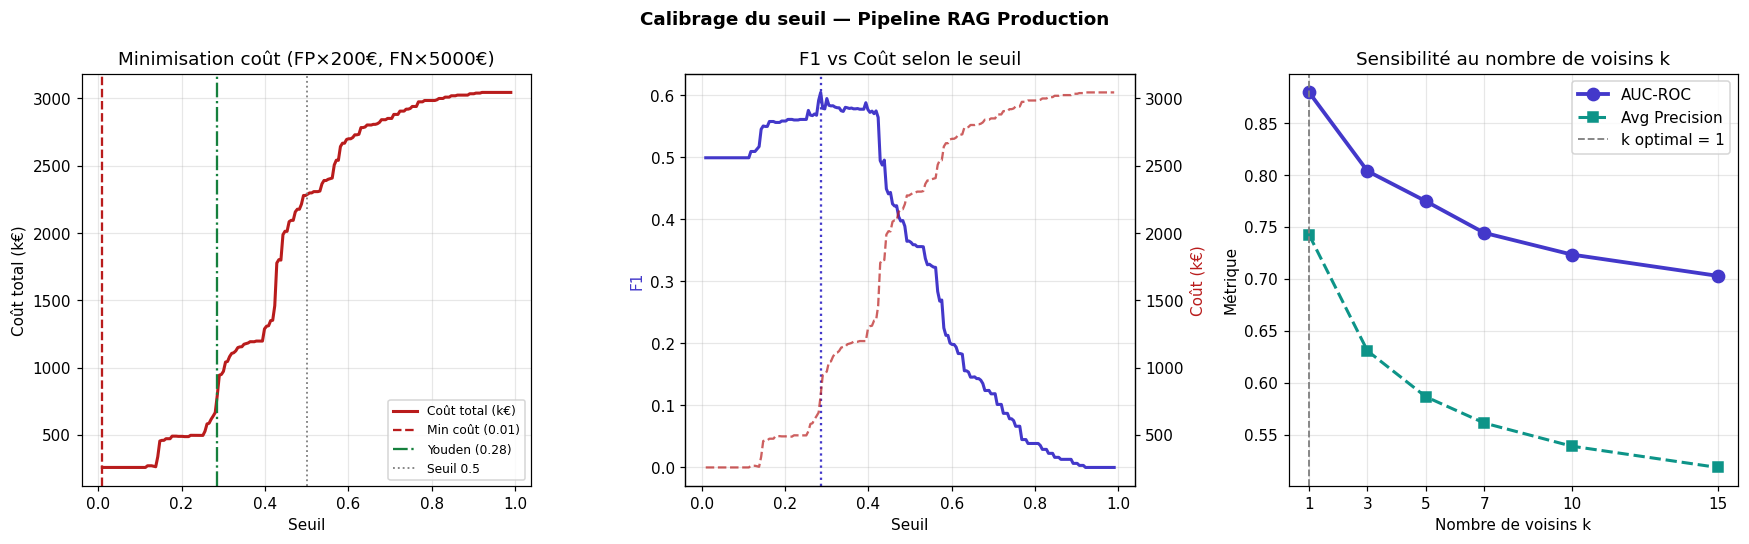

Graphiques de calibrage sauvegardés → artifacts/calibrage_prod.png


In [45]:
# ── CELLULE 10.2 : Visualisations calibrage ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Calibrage du seuil — Pipeline RAG Production",
             fontsize=12, fontweight="bold")

# 1. Coût total selon le seuil
ax = axes[0]
ax.plot(res_df["threshold"], res_df["cout"]/1000,
        color="#b91c1c", lw=2, label="Coût total (k€)")
ax.axvline(seuil_cout,   color="#b91c1c", ls="--", lw=1.5,
           label=f"Min coût ({seuil_cout:.2f})")
ax.axvline(seuil_youden, color="#15803d", ls="-.", lw=1.5,
           label=f"Youden ({seuil_youden:.2f})")
ax.axvline(0.5,          color="gray", ls=":", lw=1.2, label="Seuil 0.5")
ax.set_xlabel("Seuil"); ax.set_ylabel("Coût total (k€)")
ax.set_title(f"Minimisation coût (FP×{COUT_FP}€, FN×{COUT_FN}€)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 2. F1 et coût
ax = axes[1]
ax2 = ax.twinx()
ax.plot(res_df["threshold"], res_df["f1"],
        color="#4338ca", lw=2, label="F1")
ax2.plot(res_df["threshold"], res_df["cout"]/1000,
         color="#b91c1c", lw=1.5, ls="--", alpha=0.7, label="Coût (k€)")
ax.axvline(seuil_f1, color="#4338ca", ls=":", lw=1.5)
ax.set_xlabel("Seuil"); ax.set_ylabel("F1", color="#4338ca")
ax2.set_ylabel("Coût (k€)", color="#b91c1c")
ax.set_title("F1 vs Coût selon le seuil")
ax.grid(alpha=0.3)

# 3. Sensibilité à k
ax = axes[2]
ax.plot(k_df["k"], k_df["auc"], "o-", color="#4338ca", lw=2.5,
        markersize=8, label="AUC-ROC")
ax.plot(k_df["k"], k_df["ap"],  "s--", color="#0d9488", lw=2,
        markersize=7, label="Avg Precision")
best_k = k_df.loc[k_df["auc"].idxmax(), "k"]
ax.axvline(best_k, color="gray", ls="--", lw=1.2,
           label=f"k optimal = {best_k}")
ax.set_xlabel("Nombre de voisins k")
ax.set_ylabel("Métrique")
ax.set_title("Sensibilité au nombre de voisins k")
ax.set_xticks(k_df["k"].values)
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "calibrage_prod.png", bbox_inches="tight", dpi=120)
plt.show()
print("Graphiques de calibrage sauvegardés → artifacts/calibrage_prod.png")


---
## Module 11 — Limites & perspectives

8 limites identifiées : données synthétiques (patterns réels plus bruités), embedding généraliste (CamemBERT IARD recommandé), scalabilité ChromaDB limitée à ~500k vecteurs, AGIRA simplifiée (accès API réel requis), graphe réseau statique, hallucinations LLM résiduelles, conformité AI Act & RGPD, description libre sous-exploitée.
8 axes d'amélioration proposés : fine-tuning embedding, migration pgvector, API AGIRA réelle, graphe incrémental, NLP dédié descriptions, dashboard Streamlit/Gradio, monitoring Evidently, audit équité.

In [46]:
# ── CELLULE 11.1 : Limites techniques ────────────────────────────────────────
import textwrap

limites = {
    "1. Données synthétiques":
        "Malgré 16 règles métier et les signaux réseau, les patterns réels "
        "sont plus bruités et corrélés. Les métriques obtenues restent "
        "optimistes par construction — validation sur données réelles requise.",
    "2. Embedding généraliste":
        "all-MiniLM-L6-v2 n'est pas fine-tuné sur le vocabulaire assurantiel. "
        "En production, un modèle spécialisé (CamemBERT fine-tuné sur sinistres "
        "IARD) améliorerait la précision sémantique.",
    "3. Scalabilité au-delà de 10k":
        "ChromaDB PersistentClient supporte ~500k vecteurs. Au-delà, migrer "
        "vers PostgreSQL + pgvector ou Qdrant avec sharding et réplication.",
    "4. AGIRA simplifié":
        "L'historique inter-assureurs est simulé dans le générateur. "
        "En production réelle, l'accès à l'AGIRA nécessite une accréditation "
        "et une connexion via API sécurisée.",
    "5. Graphe réseau statique":
        "Le graphe garages/experts est calculé une fois sur l'historique. "
        "En production, il faudrait le mettre à jour en continu (streaming).",
    "6. Hallucinations LLM":
        "Même à temperature=0.1, le LLM peut inventer des motifs. "
        "La double validation Expert/Juge réduit le risque. "
        "Validation humaine obligatoire.",
    "7. Conformité AI Act & RGPD":
        "Usage à haut risque en assurance (décision individuelle). "
        "Explicabilité obligatoire, registre des systèmes IA, "
        "bilan conformité ACPR avant déploiement.",
    "8. Description libre sous-exploitée":
        "La description textuelle est encodée dans l'embedding global. "
        "Un module NLP dédié (détection de copié-collé, analyse de cohérence "
        "narrative) apporterait un signal supplémentaire.",
}

print("=" * 65)
print("LIMITES TECHNIQUES — PIPELINE RAG FRAUDE AUTO PRODUCTION")
print("=" * 65)
for titre, desc in limites.items():
    print(f"\n⚠️  {titre}")
    print(textwrap.fill(desc, width=75,
          initial_indent="   ", subsequent_indent="   "))

print(f"\n{'='*65}")
print("PERSPECTIVES D'AMÉLIORATION")
print("=" * 65)
perspectives = [
    "Fine-tuning all-MiniLM sur corpus sinistres IARD réels labelisés",
    "Migration ChromaDB → pgvector pour volumes > 500k sinistres",
    "Intégration API AGIRA réelle (accréditation requise)",
    "Graphe réseau en temps réel avec mise à jour incrémentale",
    "Module NLP dédié à l'analyse de la description libre",
    "Dashboard Streamlit/Gradio pour les gestionnaires fraude",
    "Monitoring des dérives (data drift) en production via Evidently",
    "Audit d'équité (biais géographiques, profession) avant déploiement",
]
for p in perspectives:
    print(f"  → {p}")


LIMITES TECHNIQUES — PIPELINE RAG FRAUDE AUTO PRODUCTION

⚠️  1. Données synthétiques
   Malgré 11 règles métier et les signaux réseau, les patterns réels sont
   plus bruités et corrélés. Les métriques obtenues restent optimistes par
   construction — validation sur données réelles requise.

⚠️  2. Embedding généraliste
   all-MiniLM-L6-v2 n'est pas fine-tuné sur le vocabulaire assurantiel. En
   production, un modèle spécialisé (CamemBERT fine-tuné sur sinistres
   IARD) améliorerait la précision sémantique.

⚠️  3. Scalabilité au-delà de 10k
   ChromaDB PersistentClient supporte ~500k vecteurs. Au-delà, migrer vers
   PostgreSQL + pgvector ou Qdrant avec sharding et réplication.

⚠️  4. AGIRA simplifié
   L'historique inter-assureurs est simulé dans le générateur. En
   production réelle, l'accès à l'AGIRA nécessite une accréditation et une
   connexion via API sécurisée.

⚠️  5. Graphe réseau statique
   Le graphe garages/experts est calculé une fois sur l'historique. En
   product

---
## Module 12 — API REST FastAPI (déploiement production)

3 endpoints générés dans `app.py` : `/score` (scoring hybride sans LLM, ~200 ms), `/analyze` (Expert LLM, ~2–4 s), `/analyze_with_judge` (Expert + Juge + boucle, ~5–8 s).
Lancement : `uvicorn app:app --reload --port 8000`. Documentation Swagger auto sur `/docs`. CORS activé pour les appels depuis une interface web.

In [47]:
# ── CELLULE 12.1 : Génération du fichier app.py ──────────────────────────────
# Ce code écrit app.py sur disque — à lancer EN DEHORS du notebook :
#   pip install fastapi uvicorn
#   uvicorn app:app --reload --port 8000

FASTAPI_CODE = '''
# app.py — API REST FraudScan Production (FastAPI)
# Lancement : uvicorn app:app --reload --port 8000
# Documentation Swagger auto : http://localhost:8000/docs

from fastapi import FastAPI, HTTPException, Depends
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel, Field
from typing import Optional, List
import uvicorn, time

app = FastAPI(
    title="FraudScan API — Production",
    description=(
        "API de détection de fraude assurance auto.\n"
        "Pipeline hybride : RAG sémantique + score réseau (garages/experts/AGIRA).\n"
        "Modèle : LLaMA 3.3 70B via Groq | Embeddings : all-MiniLM-L6-v2"
    ),
    version="2.0.0",
)

# CORS : autoriser les appels depuis une interface web
app.add_middleware(CORSMiddleware, allow_origins=["*"],
                   allow_methods=["*"], allow_headers=["*"])


class ClaimRequest(BaseModel):
    claim_id:               str   = Field(..., example="CLM_000001")
    insured_id:             str   = Field(..., example="INS_012345")
    incident_type:          str   = Field(..., example="Collision simple")
    incident_severity:      str   = Field(..., example="important")
    incident_date:          str   = Field(..., example="2024-08-15")
    incident_hour:          int   = Field(12, ge=0, le=23)
    incident_day_of_week:   int   = Field(0,  ge=0, le=6)
    declaration_delay_days: int   = Field(1,  ge=0)
    region:                 str   = Field(..., example="Île-de-France")
    vehicle_brand:          str   = Field(..., example="BMW")
    vehicle_age:            int   = Field(2,  ge=0, le=30)
    total_claim_amount:     float = Field(..., gt=0, example=19800.0)
    driver_age:             int   = Field(30, ge=18, le=90)
    months_as_customer:     int   = Field(24, ge=1)
    annual_income:          float = Field(..., gt=0, example=28000.0)
    profession:             str   = Field(..., example="commercial")
    witnesses:              int   = Field(0,  ge=0)
    prior_claims:           int   = Field(0,  ge=0)
    bodily_injuries:        int   = Field(0,  ge=0)
    police_report:          str   = Field("Oui", pattern="^(Oui|Non)$")
    garage_id:              str   = Field("GAR_0001")
    expert_id:              str   = Field("AUCUN")
    claims_last_36m_agira:  int   = Field(0, ge=0)
    incident_description:   str   = Field("", example="Collision sur parking.")


class ScoreResponse(BaseModel):
    claim_id:       str
    score_rag:      float
    score_network:  float
    score_final:    float
    risk_level:     str
    neighbors:      List[dict]
    latency_ms:     int


@app.get("/health")
def health():
    """Vérification que le service est opérationnel."""
    return {
        "status":       "ok",
        "model":        LLM_MODEL,
        "vector_store": collection.count(),
        "timestamp":    time.strftime("%Y-%m-%dT%H:%M:%SZ"),
    }


@app.post("/score", response_model=ScoreResponse)
def score_claim(req: ClaimRequest):
    """Scoring hybride RAG + réseau sans appel LLM (~200ms)."""
    t0    = time.time()
    claim = req.dict()
    try:
        scored = hybrid_score(claim, k=5)
        return ScoreResponse(
            claim_id=      req.claim_id,
            score_rag=     scored["score_rag"],
            score_network= scored["score_network"],
            score_final=   scored["score_final"],
            risk_level=    scored["risk_level"],
            neighbors=     [
                {
                    "claim_id":    n["metadata"]["claim_id"],
                    "fraud_label": n["metadata"]["fraud_label"],
                    "similarity":  round(n["similarity"], 4),
                    "garage_id":   n["metadata"].get("garage_id","?"),
                }
                for n in scored["neighbors"]
            ],
            latency_ms=int((time.time() - t0) * 1000),
        )
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))


@app.post("/analyze")
def analyze_claim(req: ClaimRequest):
    """Analyse complète avec Agent Expert LLM (~2-4s)."""
    t0    = time.time()
    claim = req.dict()
    try:
        scored = hybrid_score(claim, k=5)
        agent  = run_fraud_agent(claim, scored)
        return {
            "claim_id":     req.claim_id,
            "score_rag":    scored["score_rag"],
            "score_network":scored["score_network"],
            "score_final":  scored["score_final"],
            "risk_level":   scored["risk_level"],
            "analysis":     agent["content"],
            "latency_ms":   int((time.time() - t0) * 1000),
        }
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))


@app.post("/analyze_with_judge")
def analyze_with_judge(req: ClaimRequest):
    """Analyse complète Expert + validation Juge (~5-8s)."""
    t0    = time.time()
    claim = req.dict()
    try:
        scored = hybrid_score(claim, k=5)
        result = run_agent_with_retry(claim, scored, max_retries=2)
        return {
            "claim_id":     req.claim_id,
            "score_final":  scored["score_final"],
            "risk_level":   scored["risk_level"],
            "analysis":     result["agent_output"],
            "judge_verdict":result["verdict"],
            "attempts":     result["attempts"],
            "latency_ms":   int((time.time() - t0) * 1000),
        }
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))


if __name__ == "__main__":
    uvicorn.run(app, host="0.0.0.0", port=8000)
'''

with open(BASE_DIR / "app.py", "w", encoding="utf-8") as f:
    f.write(FASTAPI_CODE.strip())

print("Fichier app.py généré OK")
print("\nPour lancer l'API :")
print("  pip install fastapi uvicorn")
print("  uvicorn app:app --reload --port 8000")
print("\nEndpoints disponibles :")
print("  GET  /health             -> statut du service")
print("  POST /score              -> scoring hybride rapide (~200ms)")
print("  POST /analyze            -> analyse Expert LLM (~2-4s)")
print("  POST /analyze_with_judge -> Expert + Juge (~5-8s)")
print("  GET  /docs               -> documentation Swagger auto")


Fichier app.py généré OK

Pour lancer l'API :
  pip install fastapi uvicorn
  uvicorn app:app --reload --port 8000

Endpoints disponibles :
  GET  /health             -> statut du service
  POST /score              -> scoring hybride rapide (~200ms)
  POST /analyze            -> analyse Expert LLM (~2-4s)
  POST /analyze_with_judge -> Expert + Juge (~5-8s)
  GET  /docs               -> documentation Swagger auto


---
## Module 13 — Interface HTML FraudScan (démo interactive)

L'interface `fraudscan.html` est chargée et rendue *directement dans le notebook* via un `<iframe>` base64 — aucun serveur requis. Elle embarque la logique complète côté navigateur : scoring hybride kNN cosinus + signaux réseau (appel `http://localhost:8000/score`) et analyse LLM (appel direct Anthropic API). La fonction `display_fraudscan()` accepte un chemin et une hauteur optionnels.

*Clé API :* avant de cliquer **Analyser le sinistre**, définissez `window.ANTHROPIC_API_KEY = "sk-ant-..."` dans la console DevTools (ou modifiez la constante dans le HTML).

In [ ]:
# ── CELLULE 13.1 : Aperçu inline de l'interface FraudScan ───────────────────
# La clé Groq est injectée automatiquement depuis GROQ_API_KEY
import base64
from pathlib import Path
from IPython.display import display, HTML

def display_fraudscan(html_path: str = "fraudscan.html", height: int = 940) -> None:
    candidates = [Path(html_path), BASE_DIR / html_path]
    path = next((p for p in candidates if p.exists()), None)
    if path is None:
        raise FileNotFoundError(
            f"Fichier '{html_path}' introuvable.\n"
            f"Placez fraudscan.html dans : {BASE_DIR}"
        )

    html_content = path.read_text(encoding="utf-8")

    # Injection automatique de la clé Groq dans le champ de saisie
    if GROQ_API_KEY:
        html_content = html_content.replace(
            'id="groq-key" type="password" placeholder="gsk_..."',
            f'id="groq-key" type="password" placeholder="gsk_..." value="{GROQ_API_KEY}"'
        )

    encoded = base64.b64encode(html_content.encode("utf-8")).decode("ascii")

    display(HTML(f"""
    <div style="border:1px solid #E2E5F0;border-radius:14px;overflow:hidden;margin:6px 0;">
      <iframe
        src="data:text/html;base64,{encoded}"
        width="100%"
        height="{height}px"
        frameborder="0"
        style="display:block">
      </iframe>
    </div>
    <div style="display:flex;align-items:center;gap:10px;margin-top:8px;
                padding:10px 14px;background:#EEF2FF;border-radius:8px;
                border-left:3px solid #4F46E5;">
      <span style="font-size:13px;color:#3730A3">
        <strong>Clé Groq injectée automatiquement</strong> depuis <code style="background:#C7D2FE;padding:1px 6px;border-radius:4px">GROQ_API_KEY</code>.
        Pour la démo autonome : ouvrir <code style="background:#C7D2FE;padding:1px 6px;border-radius:4px">fraudscan.html</code>
        directement dans Chrome et entrer la clé manuellement.
      </span>
    </div>
    """))

    size_kb = path.stat().st_size / 1024
    key_status = "clé injectée" if GROQ_API_KEY else "clé manquante"
    print(f"FraudScan chargé  |  {path.name}  |  {size_kb:.1f} Ko  |  {key_status}")


display_fraudscan()